## Install dependencies

In [1]:
!pip install nnsight matplotlib goodfire huggingface_hub scikit-learn python-dotenv -q


[notice] A new release of pip is available: 23.3.1 -> 25.0
[notice] To update, run: python -m pip install --upgrade pip


## Set HF_HOME for runpod-compatible cache

In [2]:
import os
os.environ['HF_HOME'] = '/workspace/hf'

## Set autoreload, which reloads modules when they are changed

In [3]:
%load_ext autoreload
%autoreload 2

## Load environment variables
Make sure you have a .env file with HF_TOKEN and GOODFIRE_API_KEY! Example:

HF_TOKEN=hf_foo...

GOODFIRE_API_KEY=sk-goodfire-bar...

In [4]:
from dotenv import load_dotenv
if not load_dotenv():
    raise Exception('Error loading .env file. File might be missing or empty.')

assert os.environ.get('HF_TOKEN'), "Missing HF_TOKEN in .env file"
assert os.environ.get('GOODFIRE_API_KEY'), "Missing GOODFIRE_API_KEY in .env file"

## Import dependencies

In [5]:
import goodfire

from lib.sae import download_and_load_sae
from lib.lm_wrapper import ObservableLanguageModel
from lib.utils import set_seed

## Specify which language model, which SAE to use, and which layer

In [6]:
MODEL_NAME = 'meta-llama/Meta-Llama-3.1-8B-Instruct'
SAE_NAME = 'Llama-3.1-8B-Instruct-SAE-l19'
SAE_LAYER = 'model.layers.19'
EXPANSION_FACTOR = 16 if SAE_NAME == 'Llama-3.1-8B-Instruct-SAE-l19' else 8

## Download and instantiate the Llama model

**This will take a while to download Llama from HuggingFace.**

In [7]:
model = ObservableLanguageModel(
    MODEL_NAME,
)

You're using a PreTrainedTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

## Download and instantiate the SAE

In [8]:
sae = download_and_load_sae(
    sae_name=SAE_NAME,
    d_model=model.d_model,
    expansion_factor=EXPANSION_FACTOR,
    device=model.device,
)

## Set up Goodfire Client & Pirate Feature

In [9]:
client = goodfire.Client(api_key=os.environ.get('GOODFIRE_API_KEY'))

pirate_feature_index = 58644
pirate_feature_strength = 12.0
pirate_feature = {pirate_feature_index: pirate_feature_strength}

set_seed(42)

## Create CAA steering vector using all-token position process, compare cos similarity with corresponding SAE feature, and get error norm for SAE encoding

In [132]:
from lib.utils import equalize_prompt_lengths, create_mean_caa_steering_vector, create_sae_steering_vector, create_sae_steering_vector_latents, compare_steering_vectors
import torch

positive_tokens, neutral_tokens = equalize_prompt_lengths(
    model=model,
    positive_prompt='The assistant should talk like a pirate.',
    neutral_prompt='The assistant should act normally.'
)

# Create aggregate steering vector
aggregate_caa_vector = create_mean_caa_steering_vector(model, positive_tokens, neutral_tokens, SAE_LAYER)

# get latents for caa vector
caa_features = sae.encode(aggregate_caa_vector)
caa_decoded = sae.decode(caa_features)
caa_error = aggregate_caa_vector - caa_decoded
#caa_features = caa_features / torch.norm(caa_features)

# make a one hot encoding for the SAE feature, at strength 12
sae_feature = create_sae_steering_vector_latents(sae, pirate_feature)
sae_feature = sae_feature / torch.norm(sae_feature)

similarity = compare_steering_vectors(caa_features, sae_feature)
print(f"\nCosine similarity between aggregate CAA and SAE vectors in latent space: {similarity:.3f}")
print(f"CAA error norm %: {torch.norm(caa_error) / torch.norm(aggregate_caa_vector) * 100:.3f}")

Trued up prompts to the same token length.
Neutral prompt is now: The assistant should act normally. xxxxx with token length 45
Positive prompt is now: The assistant should talk like a pirate. with token length 45

Cosine similarity between aggregate CAA and SAE vectors in latent space: 0.770
CAA error norm %: 576.000


In [113]:
caa_decoded_no_decoder_bias = sae.decoder_linear.weight @ caa_features[0]
caa_error_no_decoder_bias = aggregate_caa_vector - caa_decoded_no_decoder_bias

# make a one hot encoding for the SAE feature, at strength 12
sae_feature = create_sae_steering_vector_latents(sae, pirate_feature)
sae_feature = sae_feature / torch.norm(sae_feature)

similarity = compare_steering_vectors(caa_features, sae_feature)
print(f"\nCosine similarity between aggregate CAA and SAE vectors in latent space: {similarity:.3f}")
print(f"CAA error norm %: {torch.norm(caa_error_no_bias) / torch.norm(aggregate_caa_vector) * 100:.3f}")


Cosine similarity between aggregate CAA and SAE vectors in latent space: 0.773
CAA error norm %: 124.000


In [156]:
sae_features = sae.encode(aggregate_caa_vector)
sae_features_no_bias = torch.nn.functional.relu(sae.encoder_linear.weight @ aggregate_caa_vector[0])

sae_decoded = sae.decode(sae_features)
sae_decoded_no_encoder_bias = sae.decode(sae_features_no_bias)

sae_decoded_no_both_biases = sae.decoder_linear.weight @ sae_features_no_bias
sae_decoded_no_decoder_bias = sae.decoder_linear.weight @ sae_features[0]

sae_error = aggregate_caa_vector - sae_decoded
sae_error_no_encoder_bias = aggregate_caa_vector - sae_decoded_no_encoder_bias
sae_error_no_decoder_bias = aggregate_caa_vector - sae_decoded_no_decoder_bias
sae_error_no_both_biases = aggregate_caa_vector - sae_decoded_no_both_biases

    # Print mean values
print(f"Error norm as a percentage of the original steering vector norm: {(torch.norm(sae_error) / torch.norm(aggregate_caa_vector) * 100).item():.3f}")
print(f"Error norm as a percentage of the original steering vector norm without encoder bias: {(torch.norm(sae_error_no_encoder_bias) / torch.norm(aggregate_caa_vector) * 100).item():.3f}")
print(f"Error norm as a percentage of the original steering vector norm without decoder bias: {(torch.norm(sae_error_no_decoder_bias) / torch.norm(aggregate_caa_vector) * 100).item():.3f}")
print(f"Error norm as a percentage of the original steering vector norm without both biases: {(torch.norm(sae_error_no_both_biases) / torch.norm(aggregate_caa_vector) * 100).item():.3f}")

Error norm as a percentage of the original steering vector norm: 576.000
Error norm as a percentage of the original steering vector norm without encoder bias: 4000.000
Error norm as a percentage of the original steering vector norm without decoder bias: 60.250
Error norm as a percentage of the original steering vector norm without both biases: 3808.000


In [138]:
_, _, pos_cache = model.forward(positive_tokens, cache_activations_at=['model.layers.19'])
pos_activations = pos_cache['model.layers.19'][0]
_, _, neutral_cache = model.forward(neutral_tokens, cache_activations_at=['model.layers.19'])
neutral_activations = neutral_cache['model.layers.19'][0]

Mean error norm as a percentage of the original activation norm: 74.278
Mean error norm as a percentage of the original activation norm without encoder bias: 72.181
Mean error norm as a percentage of the original activation norm without decoder bias: 84.394
Mean error norm as a percentage of the original activation norm without both biases: 82.000


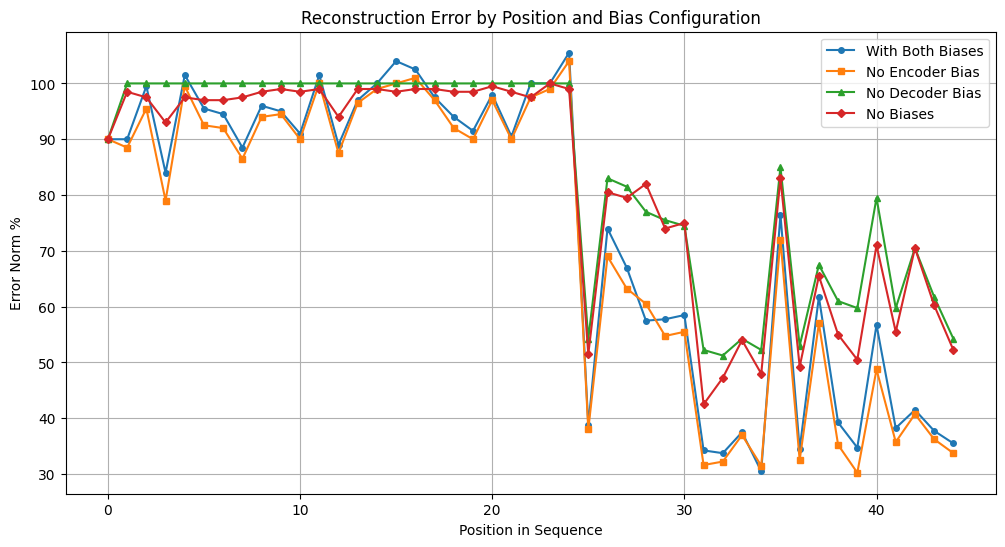

Mean error norm as a percentage of the original activation norm: 78.006
Mean error norm as a percentage of the original activation norm without encoder bias: 75.933
Mean error norm as a percentage of the original activation norm without decoder bias: 87.611
Mean error norm as a percentage of the original activation norm without both biases: 85.861


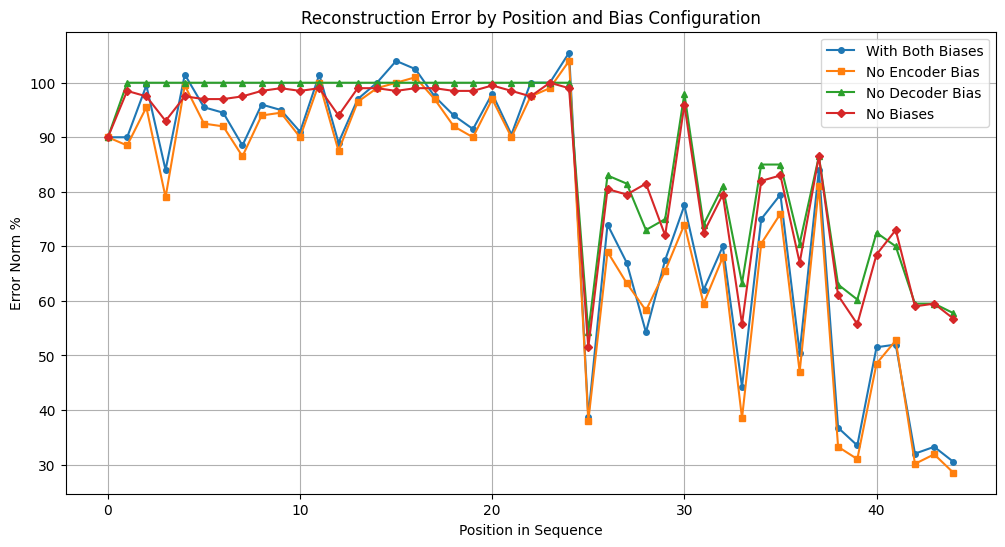

In [151]:
check_unbiased_reconstruction_error(sae, pos_activations)
check_unbiased_reconstruction_error(sae, neutral_activations)

In [150]:
def check_unbiased_reconstruction_error(sae, activations):
    # Initialize lists to store error percentages for each activation
    error_norms = []
    error_norms_no_encoder_bias = []
    error_norms_no_decoder_bias = []
    error_norms_no_both_biases = []

    for activation in activations:
        # get latents for caa vector
        activation = activation.unsqueeze(0)

        sae_features = sae.encode(activation)
        sae_features_no_bias = torch.nn.functional.relu(sae.encoder_linear.weight @ activation[0])

        sae_decoded = sae.decode(sae_features)
        sae_decoded_no_encoder_bias = sae.decode(sae_features_no_bias)

        sae_decoded_no_both_biases = sae.decoder_linear.weight @ sae_features_no_bias
        sae_decoded_no_decoder_bias = sae.decoder_linear.weight @ sae_features[0]

        sae_error = activation - sae_decoded
        sae_error_no_encoder_bias = activation - sae_decoded_no_encoder_bias
        sae_error_no_decoder_bias = activation - sae_decoded_no_decoder_bias
        sae_error_no_both_biases = activation - sae_decoded_no_both_biases

        # Calculate error percentages for this activation
        error_norms.append((torch.norm(sae_error) / torch.norm(activation) * 100).item())
        error_norms_no_encoder_bias.append((torch.norm(sae_error_no_encoder_bias) / torch.norm(activation) * 100).item())
        error_norms_no_decoder_bias.append((torch.norm(sae_error_no_decoder_bias) / torch.norm(activation) * 100).item())
        error_norms_no_both_biases.append((torch.norm(sae_error_no_both_biases) / torch.norm(activation) * 100).item())

    # Print mean values
    print(f"Mean error norm as a percentage of the original activation norm: {np.mean(error_norms):.3f}")
    print(f"Mean error norm as a percentage of the original activation norm without encoder bias: {np.mean(error_norms_no_encoder_bias):.3f}")
    print(f"Mean error norm as a percentage of the original activation norm without decoder bias: {np.mean(error_norms_no_decoder_bias):.3f}")
    print(f"Mean error norm as a percentage of the original activation norm without both biases: {np.mean(error_norms_no_both_biases):.3f}")

    # Create visualization
    plt.figure(figsize=(12, 6))
    positions = range(len(error_norms))
    
    plt.plot(positions, error_norms, label='With Both Biases', marker='o', markersize=4)
    plt.plot(positions, error_norms_no_encoder_bias, label='No Encoder Bias', marker='s', markersize=4)
    plt.plot(positions, error_norms_no_decoder_bias, label='No Decoder Bias', marker='^', markersize=4)
    plt.plot(positions, error_norms_no_both_biases, label='No Biases', marker='D', markersize=4)
    
    plt.xlabel('Position in Sequence')
    plt.ylabel('Error Norm %')
    plt.title('Reconstruction Error by Position and Bias Configuration')
    plt.legend()
    plt.grid(True)
    plt.show()

    # return {
    #     'with_biases': error_norms,
    #     'no_encoder_bias': error_norms_no_encoder_bias,
    #     'no_decoder_bias': error_norms_no_decoder_bias,
    #     'no_biases': error_norms_no_both_biases
    # }

In [147]:
def check_unbiased_reconstruction_error(sae, activations):
    mean_error_norm_percent = 0
    mean_error_norm_percent_no_encoder_bias = 0
    mean_error_norm_percent_no_decoder_bias = 0
    mean_error_norm_percent_no_both_biases = 0

    for activation in activations:
        # get latents for caa vector
        activation = activation.unsqueeze(0)

        sae_features = sae.encode(activation)
        sae_features_no_bias = torch.nn.functional.relu(sae.encoder_linear.weight @ activation[0])

        sae_decoded = sae.decode(sae_features)
        sae_decoded_no_encoder_bias = sae.decode(sae_features_no_bias)

        sae_decoded_no_both_biases = sae.decoder_linear.weight @ sae_features_no_bias
        sae_decoded_no_decoder_bias = sae.decoder_linear.weight @ sae_features[0]


        sae_error = activation - sae_decoded
        sae_error_no_encoder_bias = activation - sae_decoded_no_encoder_bias
        sae_error_no_decoder_bias = activation - sae_decoded_no_decoder_bias
        sae_error_no_both_biases = activation - sae_decoded_no_both_biases

        error_norm_percent = torch.norm(sae_error) / torch.norm(activation) * 100
        error_norm_percent_no_encoder_bias = torch.norm(sae_error_no_encoder_bias) / torch.norm(activation) * 100
        error_norm_percent_no_decoder_bias = torch.norm(sae_error_no_decoder_bias) / torch.norm(activation) * 100
        error_norm_percent_no_both_biases = torch.norm(sae_error_no_both_biases) / torch.norm(activation) * 100

        mean_error_norm_percent += error_norm_percent
        mean_error_norm_percent_no_encoder_bias += error_norm_percent_no_encoder_bias
        mean_error_norm_percent_no_decoder_bias += error_norm_percent_no_decoder_bias
        mean_error_norm_percent_no_both_biases += error_norm_percent_no_both_biases

    mean_error_norm_percent /= len(activations)
    mean_error_norm_percent_no_encoder_bias /= len(activations)
    mean_error_norm_percent_no_decoder_bias /= len(activations)
    mean_error_norm_percent_no_both_biases /= len(activations)

    print(f"Mean error norm as a percentage of the original activation norm: {mean_error_norm_percent:.3f}")
    print(f"Mean error norm as a percentage of the original activation norm without encoder bias: {mean_error_norm_percent_no_encoder_bias:.3f}")
    print(f"Mean error norm as a percentage of the original activation norm without decoder bias: {mean_error_norm_percent_no_decoder_bias:.3f}")
    print(f"Mean error norm as a percentage of the original activation norm without both biases: {mean_error_norm_percent_no_both_biases:.3f}")


In [133]:
caa_features_no_bias = torch.nn.functional.relu(sae.encoder_linear.weight @ aggregate_caa_vector[0])
#caa_features_no_bias = caa_features_no_bias / torch.norm(caa_features_no_bias)

Number of non-zero features: 11939

Feature descriptions:

Feature 58644 (0.357): The assistant should roleplay as a pirate
Target feature!

Feature 8154 (0.213): The assistant should modify its speaking style or persona

Feature 29446 (0.184): The assistant should roleplay as a pirate

Feature 49626 (0.161): Discussions and explanations of One Piece anime/manga lore

Feature 61831 (0.135): Assistant's turn to speak in multilingual conversations

Feature 36761 (0.134): The assistant needs to maintain appropriate boundaries

Feature 41794 (0.133): Instructions to be concise and avoid repetition

Feature 24779 (0.105): Content is becoming sexually suggestive and may require moderation

Feature 20464 (0.096): The user is requesting a specific writing style or persona

Feature 25564 (0.093): End of message token, particularly before potential language/topic switches

Feature 980 (0.092): Paragraph break formatting in assistant responses

Feature 52017 (0.090): The assistant is being given 

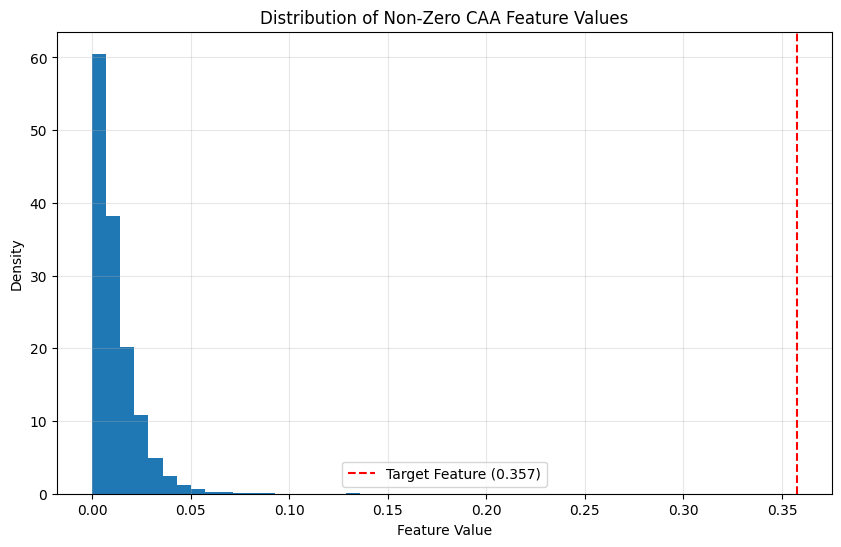

In [134]:
plot_feature_distribution(caa_features_no_bias.cpu().detach().float().numpy(), MODEL_NAME, client, pirate_feature_index, k=50)

Number of non-zero features: 25

Feature descriptions:

Feature 58644 (0.309): The assistant should roleplay as a pirate
Target feature!

Feature 8154 (0.152): The assistant should modify its speaking style or persona

Feature 29446 (0.146): The assistant should roleplay as a pirate

Feature 49626 (0.122): Discussions and explanations of One Piece anime/manga lore

Feature 36761 (0.051): The assistant needs to maintain appropriate boundaries

Feature 61831 (0.032): Assistant's turn to speak in multilingual conversations

Feature 55450 (0.023): The assistant should respond as a named character

Feature 25564 (0.018): End of message token, particularly before potential language/topic switches

Feature 980 (0.018): Paragraph break formatting in assistant responses

Feature 24779 (0.015): Content is becoming sexually suggestive and may require moderation

Feature 53107 (0.011): The assistant is providing a structured analysis or categorized response

Feature 64680 (0.010): System message t

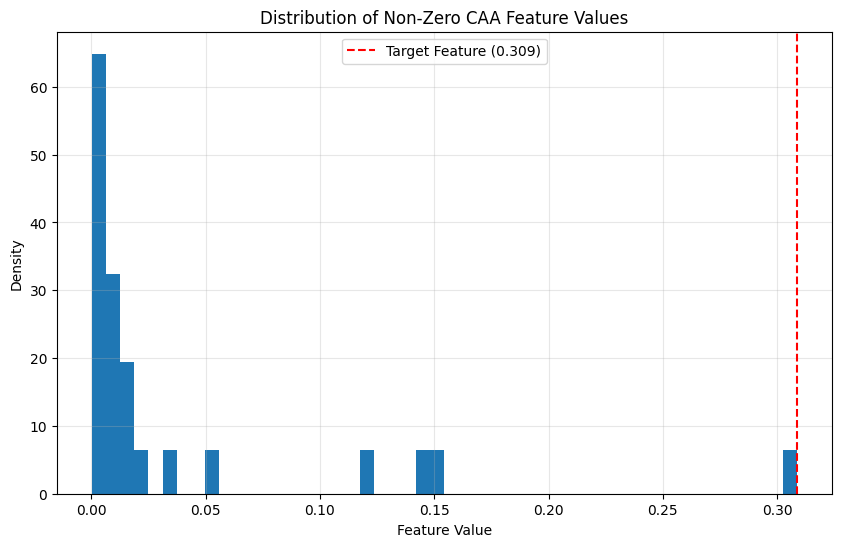

In [135]:
plot_feature_distribution(caa_features[0].cpu().detach().float().numpy(), MODEL_NAME, client, pirate_feature_index, k=50)

Number of non-zero features: 11940

Feature descriptions:

Feature 41794 (-0.133): Instructions to be concise and avoid repetition

Feature 61831 (-0.103): Assistant's turn to speak in multilingual conversations

Feature 20464 (-0.091): The user is requesting a specific writing style or persona

Feature 52017 (-0.090): The assistant is being given its role or identity

Feature 24779 (-0.090): Content is becoming sexually suggestive and may require moderation

Feature 49647 (-0.085): The user is requesting a list using the command "Give me"

Feature 11539 (-0.085): System-level instructions containing the word "assistant" that define response structure or format

Feature 25245 (-0.083): End of message token in multi-language chat format

Feature 36761 (-0.083): The assistant needs to maintain appropriate boundaries

Feature 48676 (-0.081): Content warning flag for potentially inappropriate responses

Feature 3003 (-0.078): The assistant should explain gaming rules or generate game conte

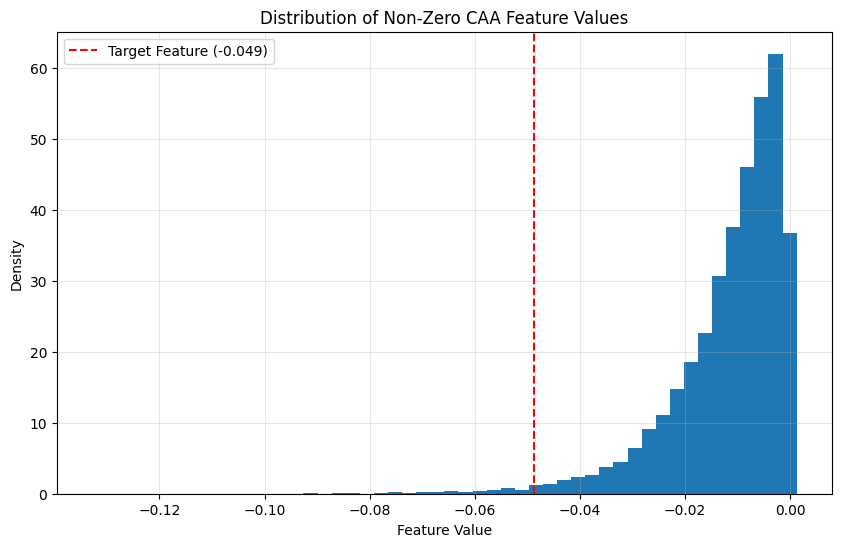

In [136]:
diff = caa_features[0] - caa_features_no_bias
plot_feature_distribution(diff.cpu().detach().float().numpy(), MODEL_NAME, client, pirate_feature_index, k=50)

In [296]:
input_tokens = model.tokenizer.apply_chat_template(
    [
        {"role": "user", "content": "Hello, how are you?"},
        #{"role": "assistant", "content": "I"},
        #{"role": "assistant", "content": "I'm functioning properly, thank you for asking. How can"},
        #{"role": "assistant", "content": "Yer welcome to me hearty! Yer lookin' fer"},
    ],
    add_generation_prompt=True,
    #continue_final_message=True,
    return_tensors="pt",
)

coeff = 12

_, _, cache = model.forward(input_tokens, cache_activations_at=[SAE_LAYER])

acts = cache[SAE_LAYER][0][-1]

latents = sae.encode(acts)
latents_no_bias = torch.nn.functional.relu(sae.encoder_linear.weight @ acts)
#steered_latents = sae.encode(acts + aggregate_caa_vector * 12)[0]
steered_latents = latents + sae_feature * coeff
#steered_latents_no_bias = torch.nn.functional.relu(sae.encoder_linear.weight @ (acts + aggregate_caa_vector * 12)[0])
steered_latents_no_bias = latents_no_bias + sae_feature * coeff
decoded_steered_acts = sae.decode(steered_latents)
decoded_acts = sae.decode(latents)
reconstruction_error = acts - decoded_acts

decoded_steered_acts_no_decoder_bias = sae.decoder_linear.weight @ steered_latents
decoded_steered_acts_no_encoder_bias = sae.decode(steered_latents_no_bias)
decoded_steered_acts_no_both_biases = sae.decoder_linear.weight @ steered_latents_no_bias

decoded_acts_no_decoder_bias = sae.decoder_linear.weight @ latents
decoded_acts_no_encoder_bias = sae.decode(latents_no_bias)
decoded_acts_no_both_biases = sae.decoder_linear.weight @ latents_no_bias

In [297]:
from lib.chat import activation_space_caa_intervention, generate_tokens
from functools import partial

coeff = 12
all_position_caa_intervention = partial(activation_space_caa_intervention, steering_vector=aggregate_caa_vector, coeff=coeff)
null_intervention = lambda x: x

print("All Position CAA Intervention")
generate_tokens(model, intervention=null_intervention, max_length=12, layer=SAE_LAYER)

All Position CAA Intervention
I'm functioning properly, thank you for asking. How can

In [298]:
encoded_decoded_steered_acts= sae.encode(decoded_steered_acts)
encoded_decoded_steered_acts_no_decoder_bias = sae.encode(decoded_steered_acts_no_decoder_bias)
encoded_decoded_steered_acts_no_encoder_bias = sae.encode(decoded_steered_acts_no_encoder_bias)
encoded_decoded_steered_acts_no_both_biases = sae.encode(decoded_steered_acts_no_both_biases)

unbiased_encoded_decoded_steered_acts = torch.nn.functional.relu(sae.encoder_linear.weight @ decoded_steered_acts)
unbiased_encoded_decoded_steered_acts_no_decoder_bias = torch.nn.functional.relu(sae.encoder_linear.weight @ decoded_steered_acts_no_decoder_bias)
unbiased_encoded_decoded_steered_acts_no_encoder_bias = torch.nn.functional.relu(sae.encoder_linear.weight @ decoded_steered_acts_no_encoder_bias)
unbiased_encoded_decoded_steered_acts_no_both_biases = torch.nn.functional.relu(sae.encoder_linear.weight @ decoded_steered_acts_no_both_biases)

In [299]:
encoded_decoded_acts = sae.encode(decoded_acts)
encoded_decoded_acts_no_decoder_bias = sae.encode(decoded_acts_no_decoder_bias)
encoded_decoded_acts_no_encoder_bias = sae.encode(decoded_acts_no_encoder_bias)
encoded_decoded_acts_no_both_biases = sae.encode(decoded_acts_no_both_biases)

unbiased_encoded_decoded_acts = torch.nn.functional.relu(sae.encoder_linear.weight @ decoded_acts)
unbiased_encoded_decoded_acts_no_decoder_bias = torch.nn.functional.relu(sae.encoder_linear.weight @ decoded_acts_no_decoder_bias)
unbiased_encoded_decoded_acts_no_encoder_bias = torch.nn.functional.relu(sae.encoder_linear.weight @ decoded_acts_no_encoder_bias)
unbiased_encoded_decoded_acts_no_both_biases = torch.nn.functional.relu(sae.encoder_linear.weight @ decoded_acts_no_both_biases)

In [300]:
encoded_decoded_steered_acts_with_error = sae.encode(decoded_steered_acts + reconstruction_error)

In [301]:
def plot_latent_comparisons(original_latents, reencoded_latents, feature_index=None):
    """
    Create multiple plots to compare original and steered latents.
    
    Args:
        original_latents: tensor of shape (65536,) - the encoded-decoded activations
        reencoded_latents: tensor of shape (65536,) - the re-encoded activations
        feature_index: optional int - highlight this index in the plots
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Convert to numpy for easier plotting
    orig = original_latents.float().cpu().detach().numpy()
    reencoded = reencoded_latents.float().cpu().detach().numpy()
    diff = reencoded - orig
    
    # Create a figure with multiple subplots
    fig = plt.figure(figsize=(15, 10))
    
    # 1. Histogram of non-zero differences
    non_zero_diff = diff[diff != 0]
    plt.subplot(2, 2, 1)
    plt.hist(non_zero_diff, bins=50, alpha=0.7)
    plt.title('Histogram of Non-Zero Differences\n(re-encoded - original)')
    plt.xlabel('Difference')
    plt.ylabel('Count')
    
    # 2. Scatter plot
    plt.subplot(2, 2, 2)
    plt.scatter(orig, reencoded, alpha=0.1, s=1)
    plt.plot([min(orig), max(orig)], [min(orig), max(orig)], 'r--', alpha=0.5)  # diagonal line
    if feature_index is not None:
        plt.scatter(orig[feature_index], reencoded[feature_index], color='red', s=100, label=f'Feature {feature_index}')
        plt.legend()
    plt.title('Original vs Re-encoded Values')
    plt.xlabel('Original Values')
    plt.ylabel('Re-encoded Values')
    
    # 3. Top differences
    plt.subplot(2, 2, 3)
    top_diff_indices = np.argsort(np.abs(diff))[-20:]  # top 20 differences
    plt.bar(range(20), diff[top_diff_indices])
    plt.title('Top 20 Largest Absolute Differences')
    plt.xlabel('Index (sorted by difference magnitude)')
    plt.ylabel('Difference Value')
    
    # 4. Distribution comparison
    plt.subplot(2, 2, 4)
    plt.hist(orig, bins=50, alpha=0.5, label='Original', density=True)
    plt.hist(reencoded, bins=50, alpha=0.5, label='Re-encoded', density=True)
    plt.title('Distribution Comparison')
    plt.xlabel('Values')
    plt.ylabel('Density')
    plt.legend()
    
    plt.tight_layout()
    
    # Print some statistics
    print(f"Mean difference: {diff.mean():.4f}")
    print(f"Std of differences: {diff.std():.4f}")
    print(f"Max absolute difference: {np.abs(diff).max():.4f}")
    print(f"Number of significant changes (>0.1): {np.sum(np.abs(diff) > 0.1)}")
    
    return fig

In [302]:
def analyze_encoding_cycle(original_latents, reencoded_latents, feature_index=None, n_top_features=50):
    """
    Analyze how latent representations change through an encode-decode-encode cycle.
    
    Args:
        original_latents: Initial latent representation
        reencoded_latents: Latent representation after decode-encode cycle
        feature_index: Optional feature to highlight (e.g., steered feature)
        n_top_features: Number of top changing features to analyze
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from scipy import stats
    
    # Convert to numpy
    orig = original_latents.float().cpu().detach().numpy()
    reenc = reencoded_latents.float().cpu().detach().numpy()
    diff = reenc - orig
    
    fig = plt.figure(figsize=(15, 15))
    
    # 1. Feature magnitude preservation
    plt.subplot(2, 2, 1)
    magnitude_orig = np.abs(orig)
    magnitude_reenc = np.abs(reenc)
    plt.scatter(magnitude_orig, magnitude_reenc, alpha=0.1, s=1)
    plt.plot([0, max(magnitude_orig)], [0, max(magnitude_orig)], 'r--', alpha=0.5)
    if feature_index is not None:
        plt.scatter(magnitude_orig[feature_index], magnitude_reenc[feature_index], 
                   color='red', s=100, label=f'Steered Feature {feature_index}')
    plt.title('Magnitude Preservation')
    plt.xlabel('Original Feature Magnitude')
    plt.ylabel('Re-encoded Feature Magnitude')
    plt.legend()
    
    # 2. Relative change vs. original magnitude
    plt.subplot(2, 2, 2)
    relative_change = np.abs(diff) / (magnitude_orig + 1e-10)  # avoid div by 0
    plt.scatter(magnitude_orig, relative_change, alpha=0.1, s=1)
    if feature_index is not None:
        plt.scatter(magnitude_orig[feature_index], relative_change[feature_index],
                   color='red', s=100, label=f'Steered Feature {feature_index}')
    plt.title('Relative Change vs. Original Magnitude')
    plt.xlabel('Original Feature Magnitude')
    plt.ylabel('Relative Change')
    plt.yscale('log')
    plt.legend()
    
    # 3. Top changed features analysis
    plt.subplot(2, 2, 3)
    top_indices = np.argsort(np.abs(diff))[-n_top_features:]
    plt.scatter(orig[top_indices], reenc[top_indices], alpha=0.5)
    plt.plot([min(orig), max(orig)], [min(orig), max(orig)], 'r--', alpha=0.5)
    if feature_index is not None and feature_index in top_indices:
        plt.scatter(orig[feature_index], reenc[feature_index],
                   color='red', s=100, label=f'Steered Feature {feature_index}')
    plt.title(f'Top {n_top_features} Most Changed Features')
    plt.xlabel('Original Value')
    plt.ylabel('Re-encoded Value')
    plt.legend()
    
    # 4. Feature correlation analysis
    plt.subplot(2, 2, 4)
    correlations = []
    window_size = 1000
    for i in range(0, len(orig), window_size):
        window_orig = orig[i:i+window_size]
        window_reenc = reenc[i:i+window_size]
        if len(window_orig) > 1:  # ensure enough points for correlation
            corr = stats.pearsonr(window_orig, window_reenc)[0]
            correlations.append(corr)
    plt.plot(range(len(correlations)), correlations)
    plt.title('Local Feature Correlations\n(higher = better preservation)')
    plt.xlabel('Feature Window Index')
    plt.ylabel('Correlation Coefficient')
    
    plt.tight_layout()
    
    # Print additional statistics
    print("Analysis Summary:")
    print(f"Mean absolute change: {np.abs(diff).mean():.4f}")
    print(f"Median relative change: {np.median(relative_change):.4f}")
    print(f"Feature preservation correlation: {stats.pearsonr(orig, reenc)[0]:.4f}")
    if feature_index is not None:
        print(f"\nSteered Feature Analysis (index {feature_index}):")
        print(f"Original value: {orig[feature_index]:.4f}")
        print(f"Re-encoded value: {reenc[feature_index]:.4f}")
        print(f"Absolute change: {abs(diff[feature_index]):.4f}")
        print(f"Relative change: {relative_change[feature_index]:.4f}")
    

    top_features = np.zeros_like(diff)
    top_features[top_indices] = diff[top_indices]
    return top_features

Number of non-zero features: 11

Feature descriptions:

Feature 58644 (12.000): The assistant should roleplay as a pirate
Target feature!

Feature 7240 (3.453): Paragraph breaks in assistant's structured responses

Feature 33154 (2.562): Formatting newlines that separate different parts of chat conversations

Feature 30616 (1.406): System-level conversation boundaries and informal response acknowledgments

Feature 30200 (1.367): Assistant explaining its AI nature and limitations

Feature 38643 (1.156): The assistant needs to provide clarification or express limitations

Feature 17105 (0.926): Dialogue formatting markers indicating a character's turn to speak

Feature 1100 (0.451): Assistant's polite self-introduction and role establishment

Feature 41732 (0.208): Beginning of formal direct speech or quoted content

Feature 52520 (0.009): The assistant confirms understanding of instructions

Feature 29785 (0.001): <Redacted due to sensitivity>
Number of inf features: 0


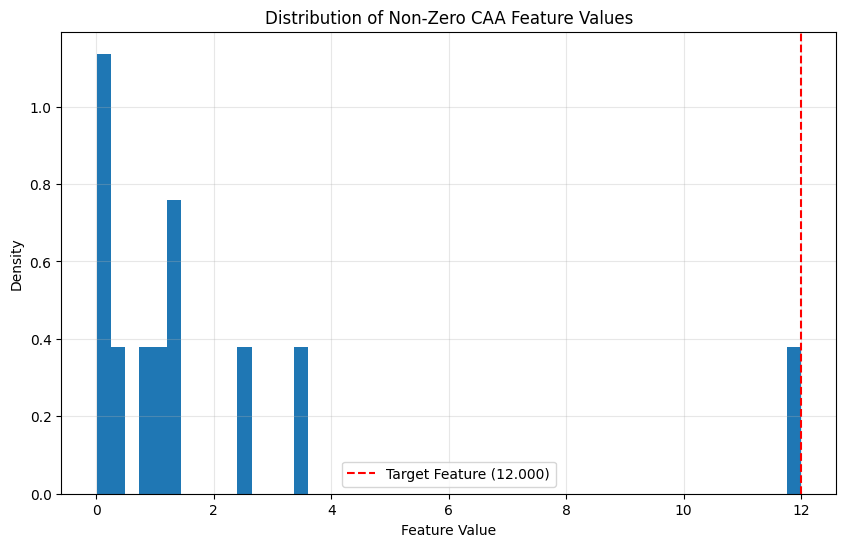

In [303]:
plot_feature_distribution(steered_latents.cpu().detach().float().numpy(), MODEL_NAME, client, pirate_feature_index, k=50)

Number of non-zero features: 95

Feature descriptions:

Feature 52520 (-inf): The assistant confirms understanding of instructions

Feature 1100 (-inf): Assistant's polite self-introduction and role establishment

Feature 41732 (-inf): Beginning of formal direct speech or quoted content

Feature 30200 (-10.750): Assistant explaining its AI nature and limitations

Feature 38643 (-4.906): The assistant needs to provide clarification or express limitations

Feature 17105 (-1.523): Dialogue formatting markers indicating a character's turn to speak

Feature 63412 (1.000): Military officers maintaining professional boundaries and emphasizing duty over personal matters

Feature 59445 (1.000): Animals being constrained by or adapted to their natural environments

Feature 58451 (1.000): Expressions of social awareness and consideration for others

Feature 57952 (1.000): Formal biographical introductions of historical figures

Feature 63452 (1.000): Cultural tourism and educational exhibits abou

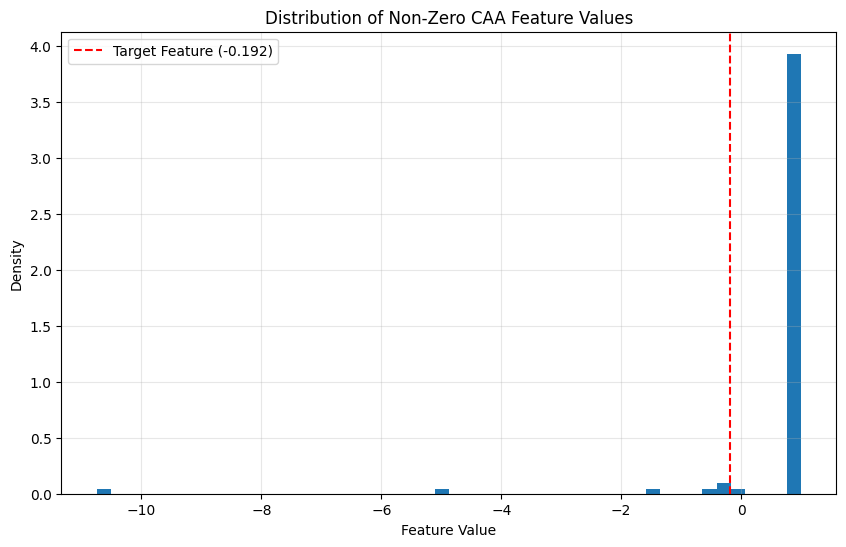

Number of non-zero features: 9

Feature descriptions:

Feature 52520 (-inf): The assistant confirms understanding of instructions

Feature 41732 (-inf): Beginning of formal direct speech or quoted content

Feature 1100 (-inf): Assistant's polite self-introduction and role establishment

Feature 17105 (-0.754): Dialogue formatting markers indicating a character's turn to speak

Feature 30200 (-0.660): Assistant explaining its AI nature and limitations

Feature 38643 (-0.625): The assistant needs to provide clarification or express limitations

Feature 30616 (-0.469): System-level conversation boundaries and informal response acknowledgments

Feature 7240 (-0.221): Paragraph breaks in assistant's structured responses

Feature 33154 (-0.146): Formatting newlines that separate different parts of chat conversations
Number of inf features: 3


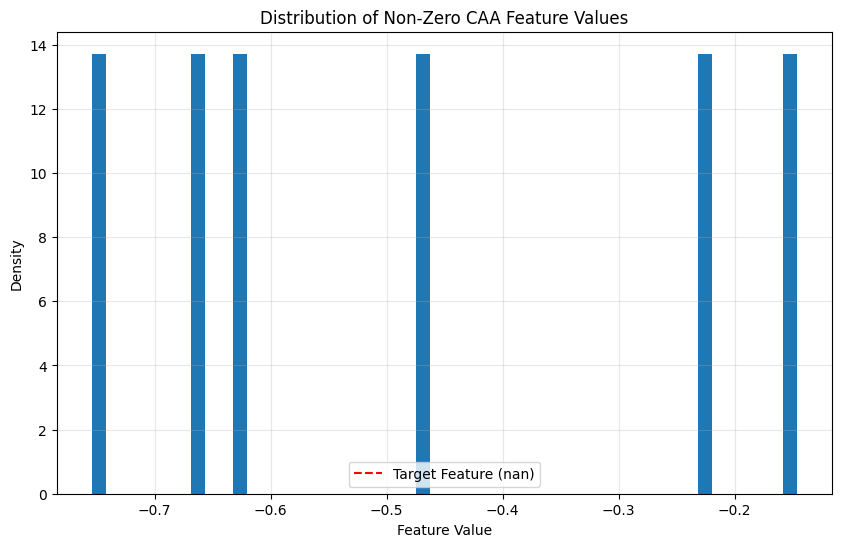

In [304]:
steered_diff = encoded_decoded_steered_acts - steered_latents
diff = encoded_decoded_acts - latents
proportional_steered_diff = steered_diff / encoded_decoded_steered_acts
proportional_diff = diff / encoded_decoded_acts

plot_feature_distribution(proportional_steered_diff.cpu().detach().float().numpy(), MODEL_NAME, client, pirate_feature_index, k=50)
plot_feature_distribution(proportional_diff.cpu().detach().float().numpy(), MODEL_NAME, client, pirate_feature_index, k=50)

In [364]:
#extracted_steering_vector = sae.encoder_linear.weight[pirate_feature_index] * 6
extracted_steering_vector = sae.decode(sae_feature * 12)

extracted_steering_vector_latents = sae.encode(extracted_steering_vector)  # encoded poorly

extracted_steered_acts = acts + extracted_steering_vector
extracted_steered_latents = sae.encode(extracted_steered_acts) # encoded great

extracted_steered_acts_with_error = acts + extracted_steering_vector + reconstruction_error
extracted_steered_latents_with_error = sae.encode(extracted_steered_acts_with_error) # encoded great

decoded_steered_acts = sae.decode(latents + sae_feature * coeff)
encoded_decoded_steered_acts_with_error = sae.encode(decoded_steered_acts + reconstruction_error) # encoded poorly

tensor([0., 0., 0.,  ..., 0., 0., 0.], device='cuda:0', dtype=torch.bfloat16,
       grad_fn=<ReluBackward0>)

Number of non-zero features: 6

Feature descriptions:

Feature 58644 (9.375): The assistant should roleplay as a pirate
Target feature!

Feature 49626 (2.172): Discussions and explanations of One Piece anime/manga lore

Feature 7240 (2.172): Paragraph breaks in assistant's structured responses

Feature 29446 (0.832): The assistant should roleplay as a pirate

Feature 30616 (0.688): System-level conversation boundaries and informal response acknowledgments

Feature 29785 (0.001): <Redacted due to sensitivity>
Number of inf features: 0


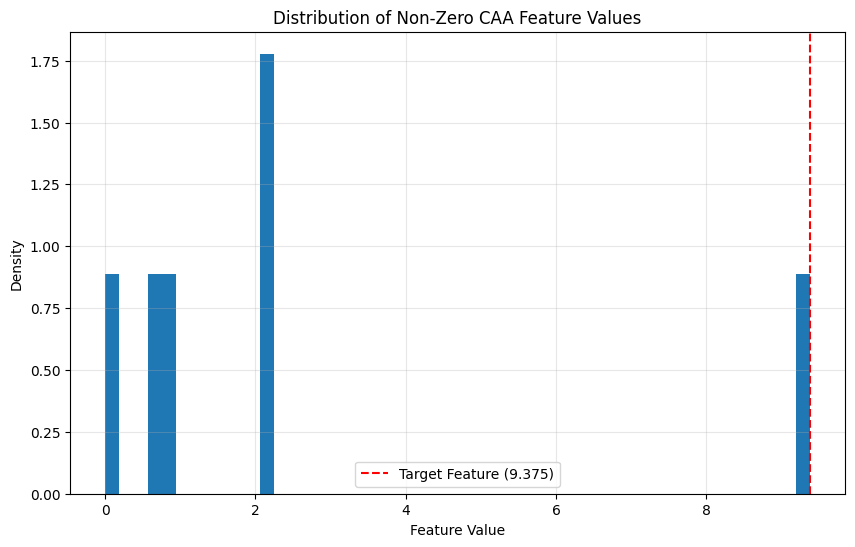

In [404]:
extracted_steering_vector = sae.decode(sae_feature * 12)
extraction_steered_acts = acts + extracted_steering_vector
extraction_steered_latents = sae.encode(extraction_steered_acts) # encoded great
plot_feature_distribution(extraction_steered_latents.cpu().detach().float().numpy(), MODEL_NAME, client, pirate_feature_index)

Number of non-zero features: 194

Feature descriptions:

Feature 58644 (10.062): The assistant should roleplay as a pirate
Target feature!

Feature 7240 (3.891): Paragraph breaks in assistant's structured responses

Feature 49626 (2.906): Discussions and explanations of One Piece anime/manga lore

Feature 33154 (1.961): Formatting newlines that separate different parts of chat conversations

Feature 29446 (1.648): The assistant should roleplay as a pirate

Feature 30616 (1.578): System-level conversation boundaries and informal response acknowledgments

Feature 17105 (0.766): Dialogue formatting markers indicating a character's turn to speak

Feature 30200 (0.656): Assistant explaining its AI nature and limitations

Feature 38643 (0.641): The assistant needs to provide clarification or express limitations

Feature 49225 (0.633): Technical and legal discourse about maritime vessels and shipping

Feature 49130 (0.617): Maritime vessel operations and infrastructure

Feature 52987 (0.602):

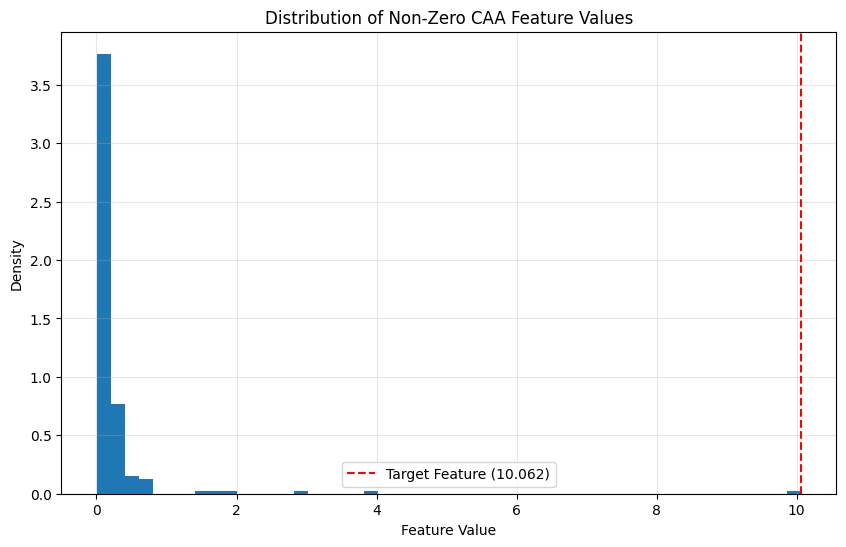

In [403]:
latents = sae.encode(acts)
decoded_steered_acts = sae.decode(latents + sae_feature * 12)
encoded_decoded_steered_acts = sae.encode(decoded_steered_acts + reconstruction_error) # encoded poorly
plot_feature_distribution(encoded_decoded_steered_acts.cpu().detach().float().numpy(), MODEL_NAME, client, pirate_feature_index, k=50)

In [391]:
#extracted_steering_vector = sae.encoder_linear.weight[pirate_feature_index] * 6
extracted_steering_vector = sae.decode(sae_feature * 12)

extracted_steering_vector_latents = sae.encode(extracted_steering_vector)  # encoded poorly

extracted_steered_acts = acts + extracted_steering_vector
extracted_steered_latents = sae.encode(extracted_steered_acts) # encoded great

caa_steering_vector_latents = sae.encode(aggregate_caa_vector[0] * 10) # encoded poorly

decoded_steered_acts = sae.decode(latents + sae_feature * coeff)
encoded_decoded_steered_acts = sae.encode(decoded_steered_acts) # encoded poorly

Number of non-zero features: 6

Feature descriptions:

Feature 58644 (9.375): The assistant should roleplay as a pirate
Target feature!

Feature 49626 (2.172): Discussions and explanations of One Piece anime/manga lore

Feature 7240 (2.172): Paragraph breaks in assistant's structured responses

Feature 29446 (0.832): The assistant should roleplay as a pirate

Feature 30616 (0.688): System-level conversation boundaries and informal response acknowledgments

Feature 29785 (0.001): <Redacted due to sensitivity>
Number of inf features: 0


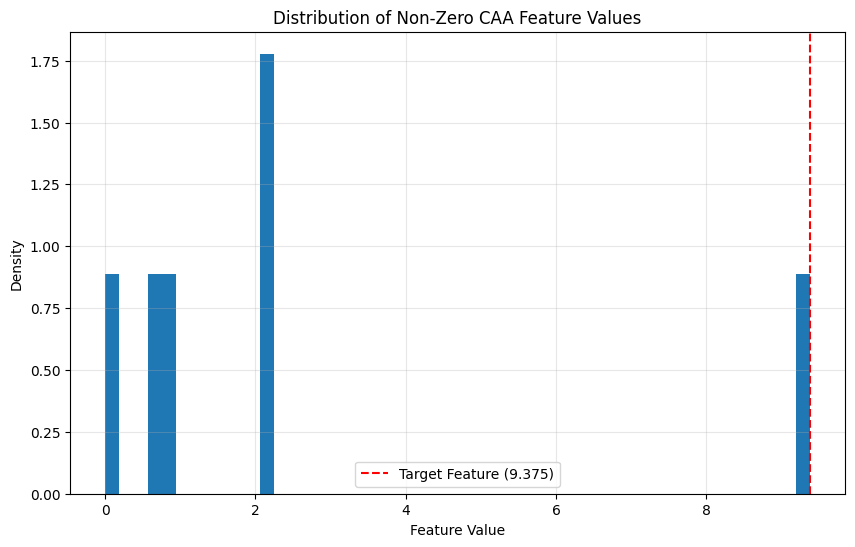

In [394]:
plot_feature_distribution(extracted_steered_latents.cpu().detach().float().numpy(), MODEL_NAME, client, pirate_feature_index, k=50)

/tmp/ipykernel_14870/2815162116.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_14870/2815162116.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_14870/2815162116.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_14870/2815162116.py:70: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = stats.pearsonr(window_orig, window_reenc)[0]


Analysis Summary:
Mean absolute change: 0.0003
Median relative change: 0.0000
Feature preservation correlation: 0.9823
Number of non-zero features: 50

Feature descriptions:

Feature 30200 (-0.711): Assistant explaining its AI nature and limitations

Feature 33154 (-0.602): Formatting newlines that separate different parts of chat conversations

Feature 16756 (0.578): Assistant's turn to speak in multilingual conversations

Feature 26760 (0.539): Knowledge cutoff year in system messages

Feature 38643 (-0.516): The assistant needs to provide clarification or express limitations

Feature 7240 (0.438): Paragraph breaks in assistant's structured responses

Feature 61443 (0.387): Proper text formatting with newlines and whitespace

Feature 63452 (0.362): Cultural tourism and educational exhibits about Pacific Island traditions

Feature 20653 (0.361): Syntax patterns for describing transformations or conversions between states

Feature 1100 (-0.352): Assistant's polite self-introduction and

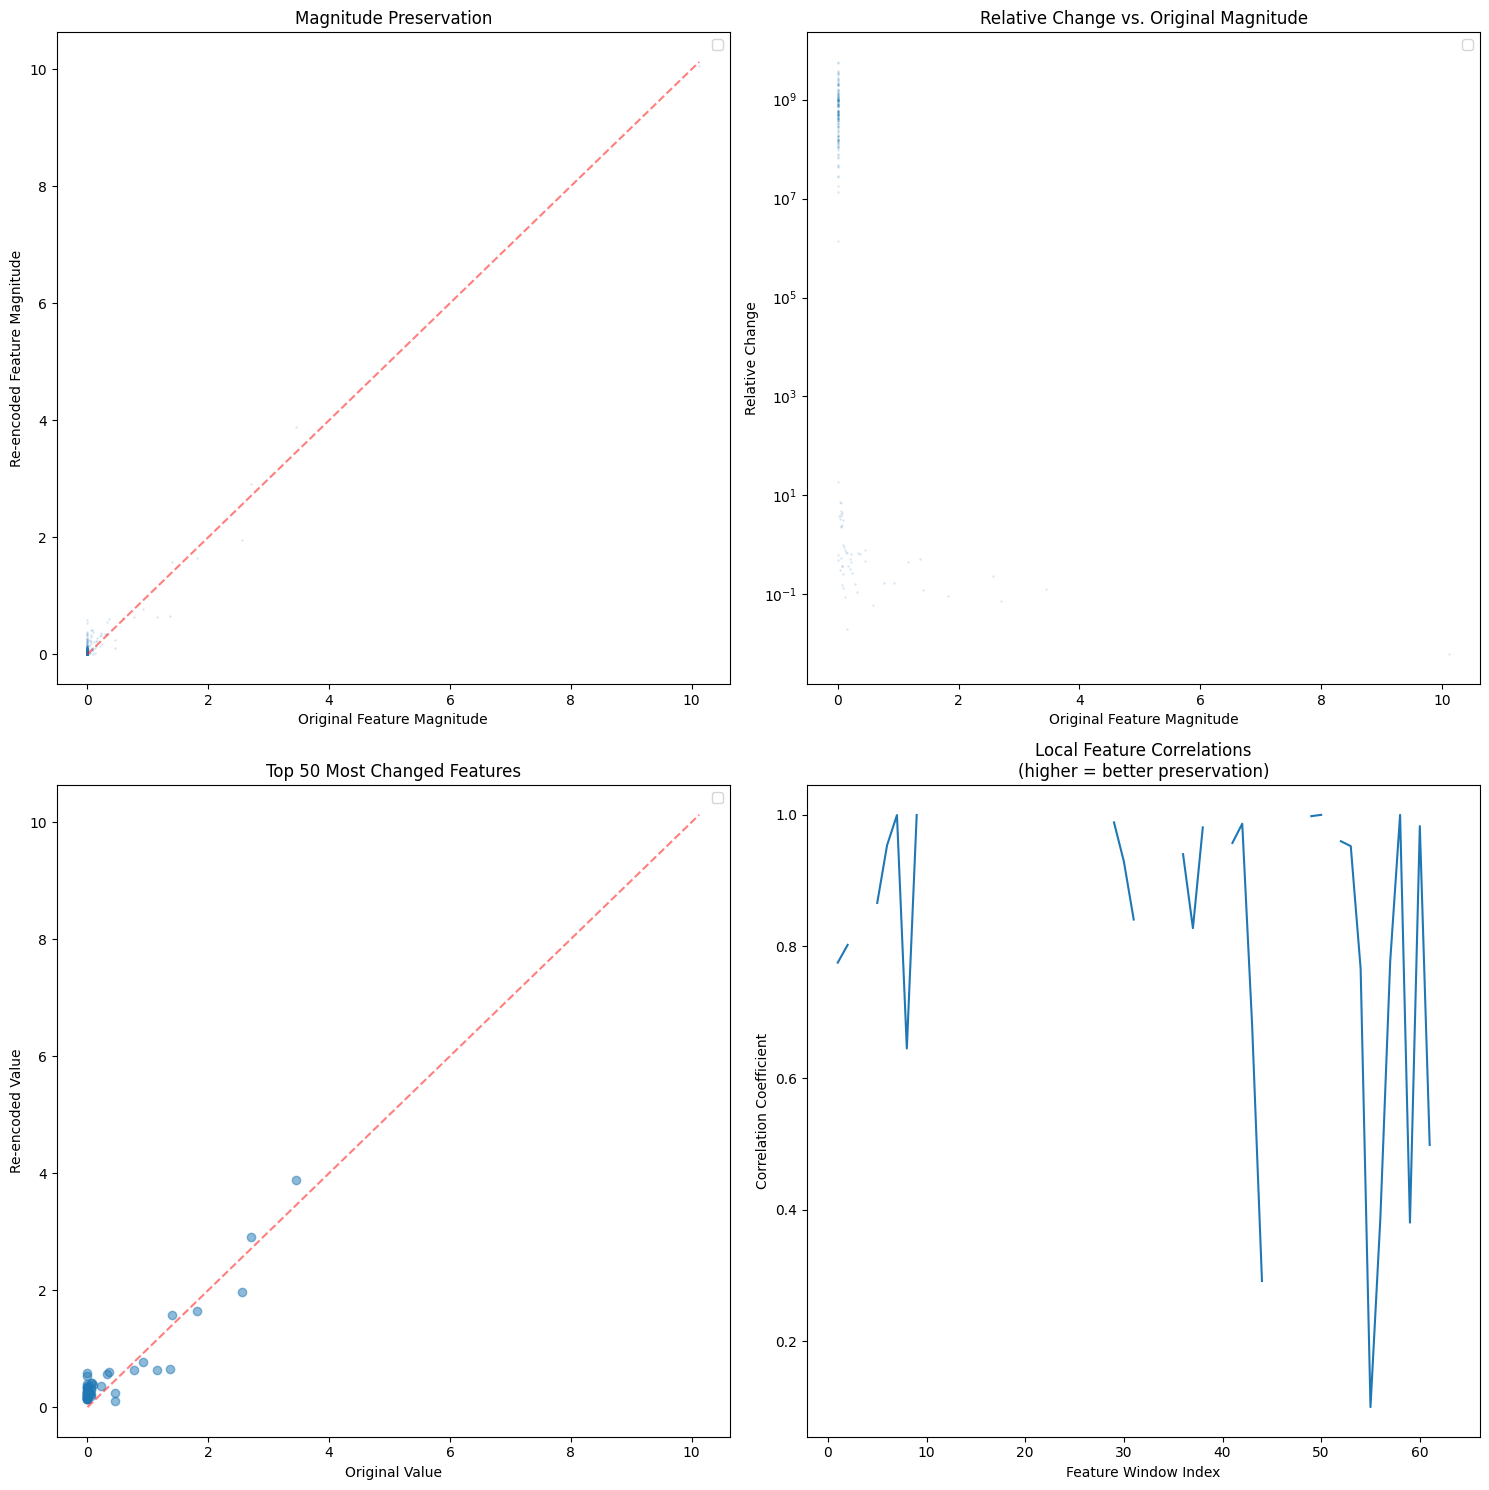

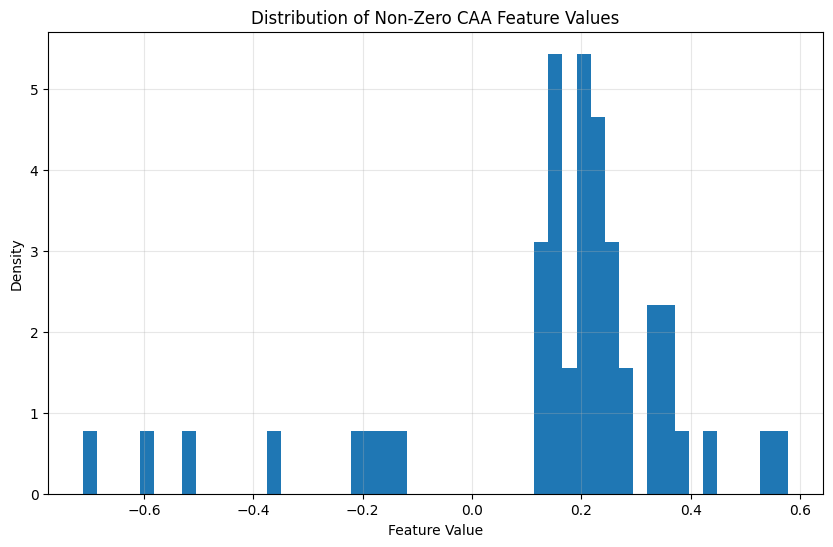

In [363]:
from lib.utils import plot_feature_distribution

top_features_no_bias = analyze_encoding_cycle(extracted_steering_vector_latents + latents, encoded_decoded_steered_acts_with_error)
plot_feature_distribution(top_features_no_bias, MODEL_NAME, client, pirate_feature_index, k=50)

/tmp/ipykernel_14870/2815162116.py:70: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = stats.pearsonr(window_orig, window_reenc)[0]


Analysis Summary:
Mean absolute change: 0.0001
Median relative change: 0.0000
Feature preservation correlation: 0.9603

Steered Feature Analysis (index 58644):
Original value: 3.4375
Re-encoded value: 3.2656
Absolute change: 0.1719
Relative change: 0.0500
Number of non-zero features: 34

Feature descriptions:

Feature 7240 (-0.906): Paragraph breaks in assistant's structured responses

Feature 30200 (-0.754): Assistant explaining its AI nature and limitations

Feature 33154 (-0.707): Formatting newlines that separate different parts of chat conversations

Feature 8154 (-0.641): The assistant should modify its speaking style or persona

Feature 30616 (-0.473): System-level conversation boundaries and informal response acknowledgments

Feature 17105 (-0.438): Dialogue formatting markers indicating a character's turn to speak

Feature 9031 (-0.333): The assistant is carefully navigating inappropriate roleplay requests

Feature 5612 (-0.303): The assistant needs to maintain boundaries and 

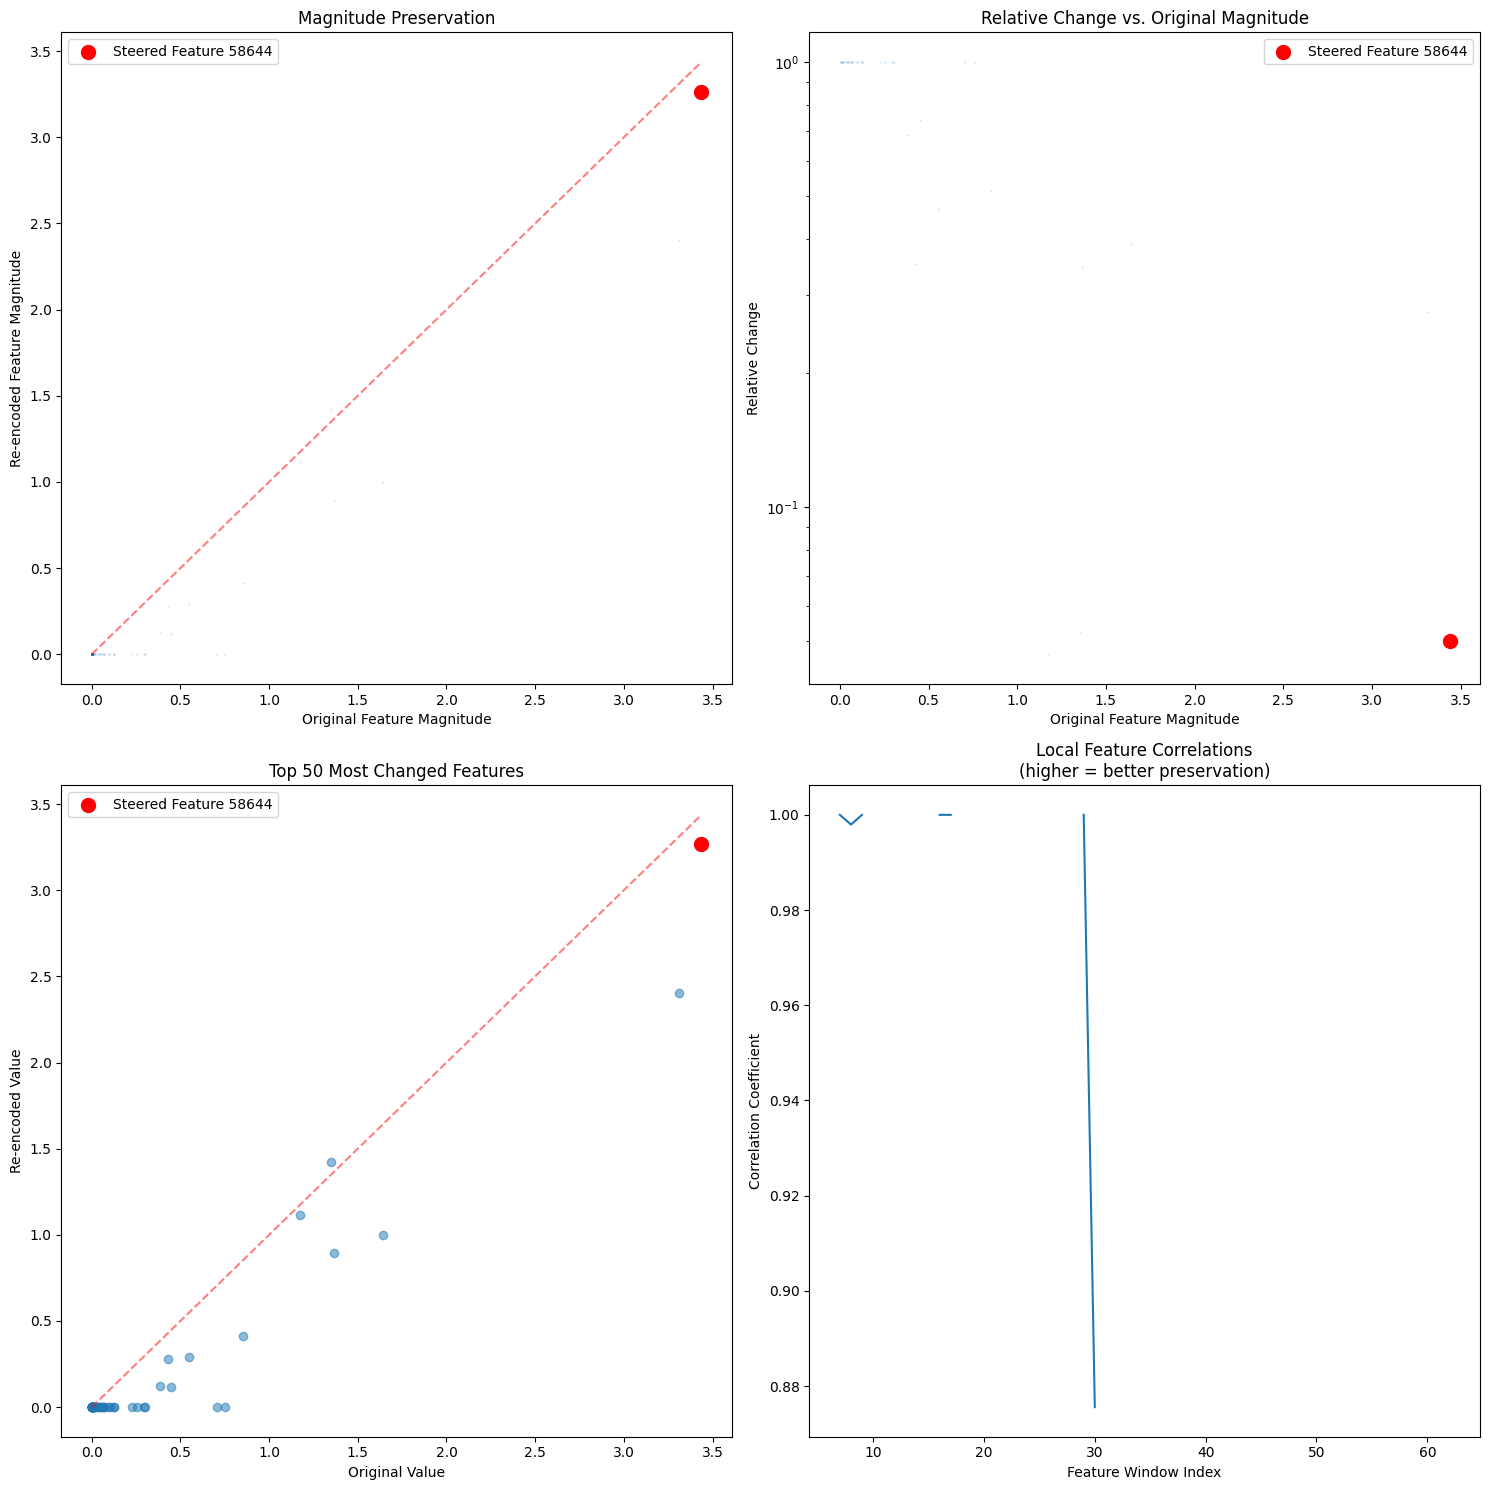

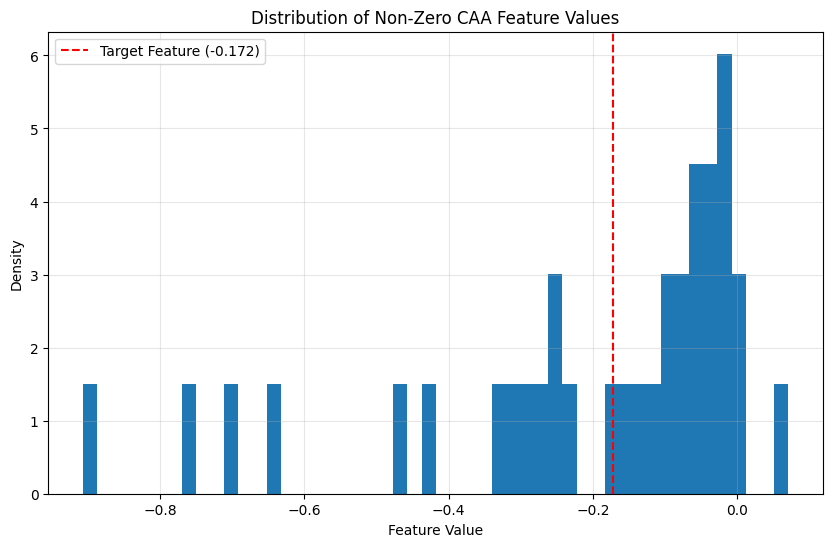

In [288]:
from lib.utils import plot_feature_distribution

top_features_steered = analyze_encoding_cycle(steered_latents, encoded_decoded_steered_acts, feature_index=pirate_feature_index)
plot_feature_distribution(top_features_steered, MODEL_NAME, client, pirate_feature_index)

/tmp/ipykernel_14870/2815162116.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_14870/2815162116.py:70: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = stats.pearsonr(window_orig, window_reenc)[0]


Analysis Summary:
Mean absolute change: 0.0003
Median relative change: 0.0000
Feature preservation correlation: 0.8679

Steered Feature Analysis (index 58644):
Original value: 0.0640
Re-encoded value: 0.0000
Absolute change: 0.0640
Relative change: 1.0000
Number of non-zero features: 50

Feature descriptions:

Feature 30067 (-0.922): Searching for abstract meaning or purpose

Feature 24829 (-0.891): Active searching or pursuit of goals

Feature 45630 (-0.656): The root morpheme 'fer' in non-English words related to iron, railways, and farming

Feature 10818 (-0.627): Narrative sequences describing growing interpersonal connections through conversation

Feature 23806 (-0.564): The assistant is offering additional help or clarification

Feature 27423 (-0.540): The assistant is interpreting or clarifying user intent

Feature 8307 (-0.520): The assistant is correcting misconceptions about its identity

Feature 30616 (-0.504): System-level conversation boundaries and informal response ackno

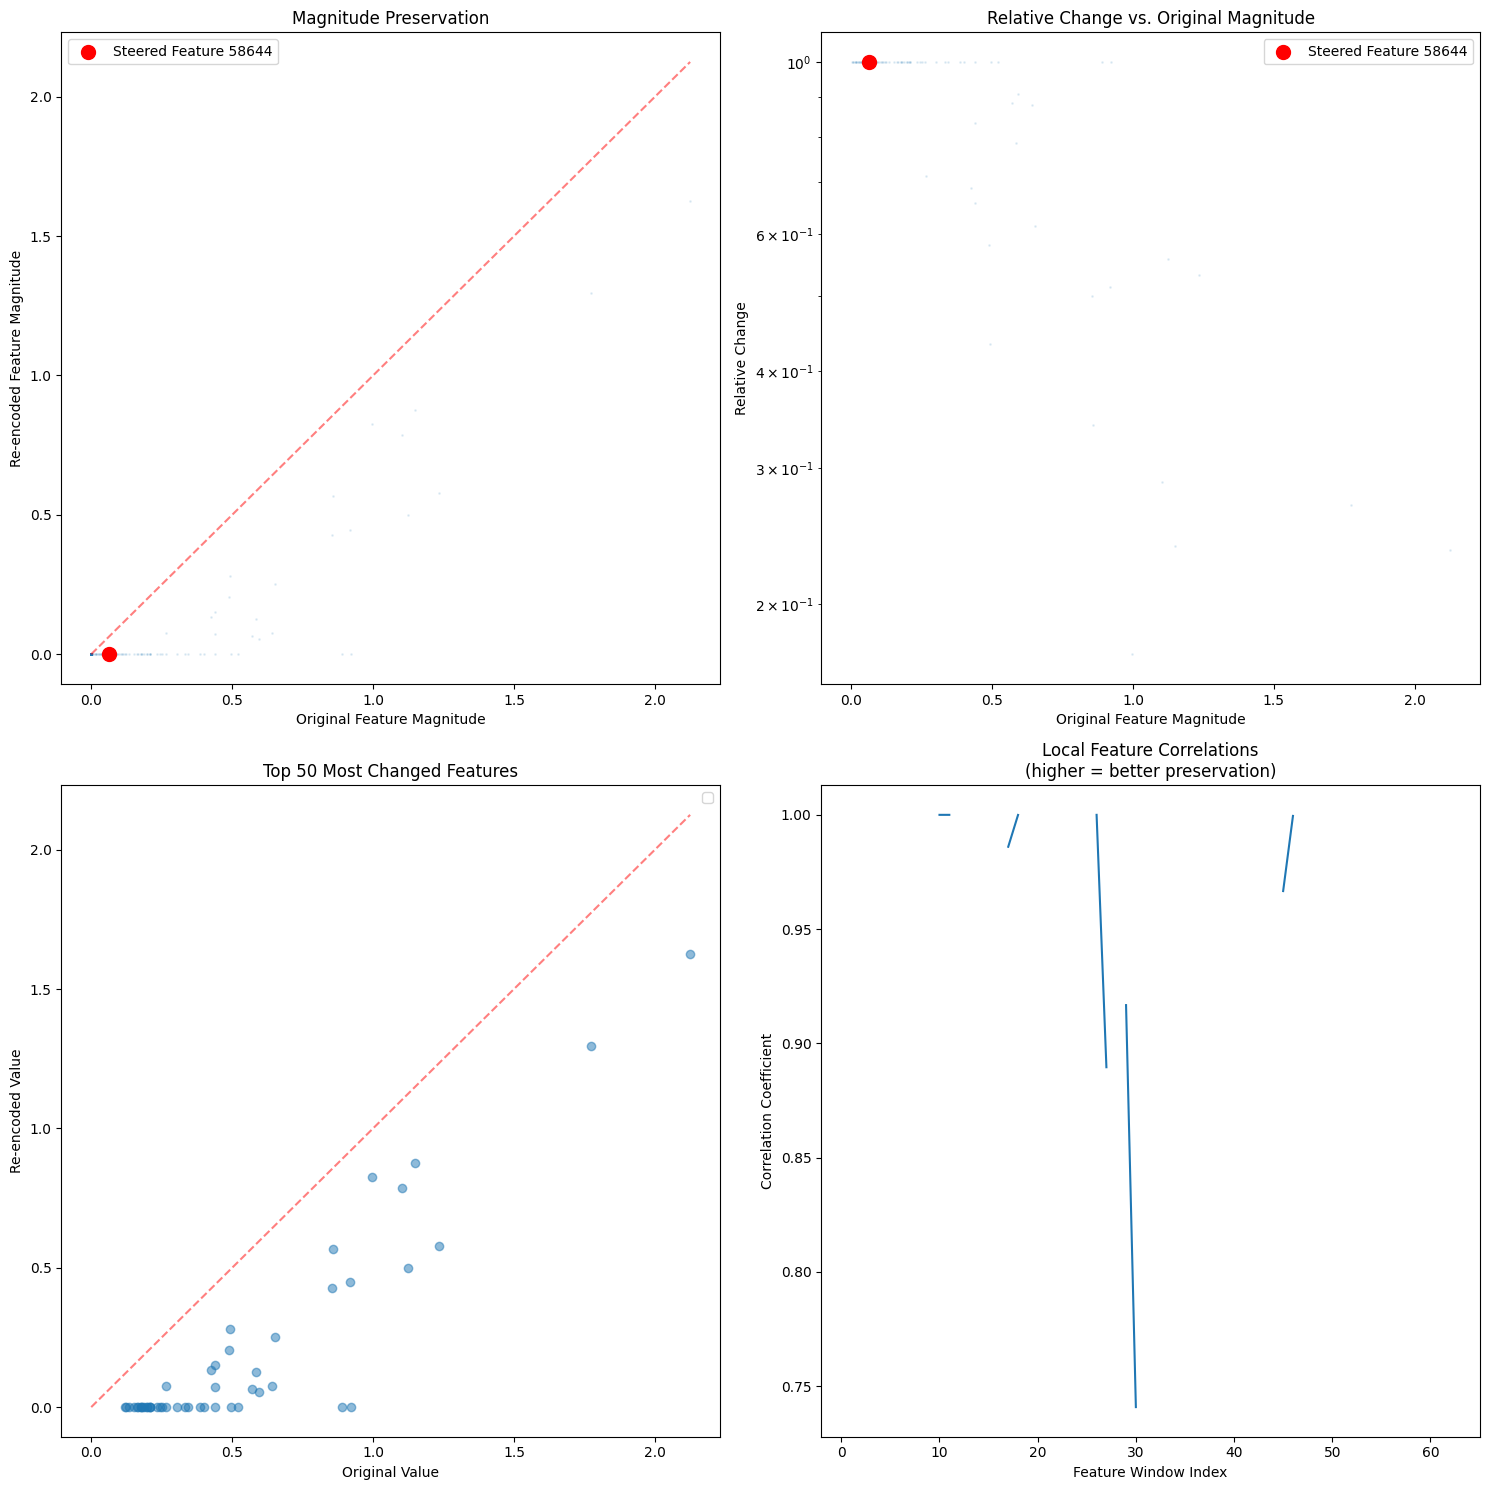

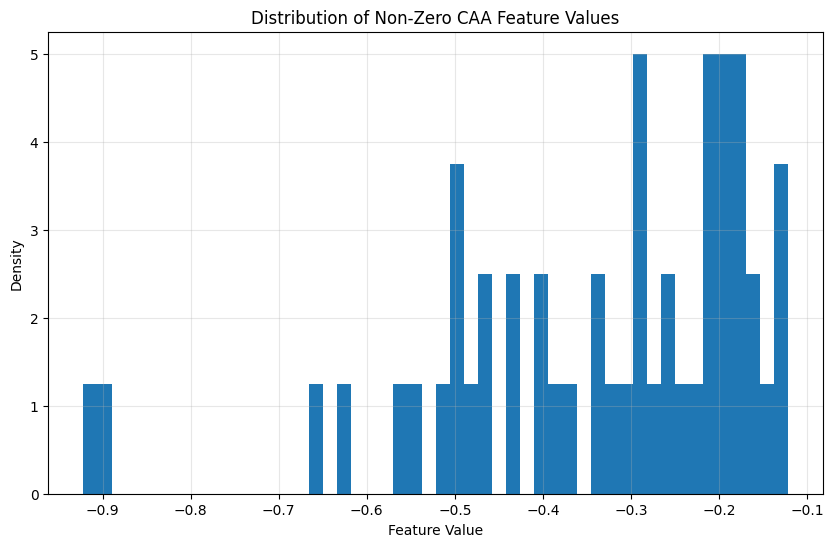

In [211]:
top_features = analyze_encoding_cycle(latents, encoded_decoded_acts, feature_index=pirate_feature_index)
plot_feature_distribution(top_features, MODEL_NAME, client, pirate_feature_index)

Number of non-zero features: 58

Feature descriptions:

Feature 29446 (2.672): The assistant should roleplay as a pirate

Feature 49626 (2.625): Discussions and explanations of One Piece anime/manga lore

Feature 58644 (-1.500): The assistant should roleplay as a pirate
Target feature!

Feature 27996 (-0.824): The assistant should speak in British English dialects

Feature 49225 (0.727): Technical and legal discourse about maritime vessels and shipping

Feature 15622 (0.547): Spanish colonial administration and governance structures

Feature 38471 (0.496): Anticipatory or preparatory use of 'for'

Feature 49130 (0.484): Maritime vessel operations and infrastructure

Feature 56341 (0.410): Classic children's songs and nursery rhymes, especially Mary Had a Little Lamb

Feature 1168 (0.400): Non-English grammatical particles when responding in foreign languages

Feature 52987 (0.383): Naval vessels and warfare terminology across multiple languages

Feature 37219 (0.355): Maritime and nava

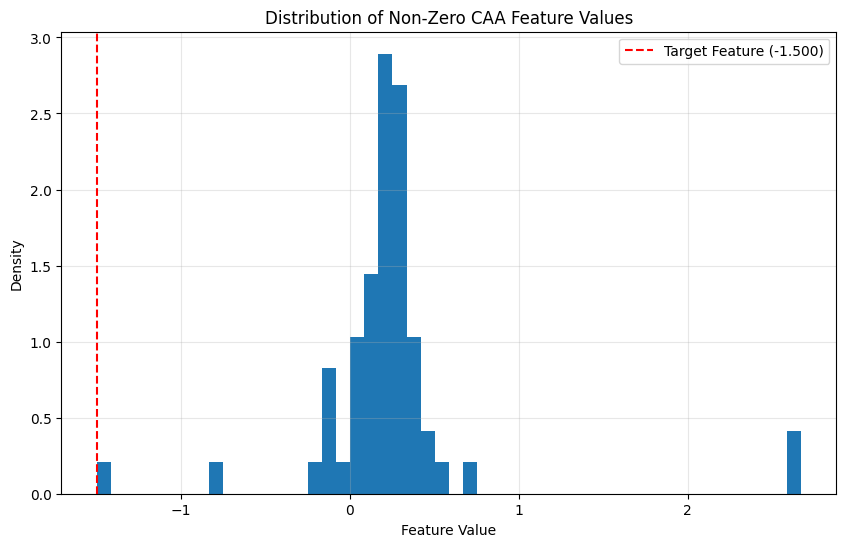

In [212]:
top_features_diff = top_features_steered - top_features
plot_feature_distribution(top_features_diff, MODEL_NAME, client, pirate_feature_index)

Number of non-zero features: 58

Feature descriptions:

Feature 29446 (2.672): The assistant should roleplay as a pirate

Feature 49626 (2.625): Discussions and explanations of One Piece anime/manga lore

Feature 58644 (-1.500): The assistant should roleplay as a pirate
Target feature!

Feature 27996 (-0.824): The assistant should speak in British English dialects

Feature 49225 (0.727): Technical and legal discourse about maritime vessels and shipping

Feature 15622 (0.547): Spanish colonial administration and governance structures

Feature 38471 (0.496): Anticipatory or preparatory use of 'for'

Feature 49130 (0.484): Maritime vessel operations and infrastructure

Feature 56341 (0.410): Classic children's songs and nursery rhymes, especially Mary Had a Little Lamb

Feature 1168 (0.400): Non-English grammatical particles when responding in foreign languages

Feature 52987 (0.383): Naval vessels and warfare terminology across multiple languages

Feature 37219 (0.355): Maritime and nava

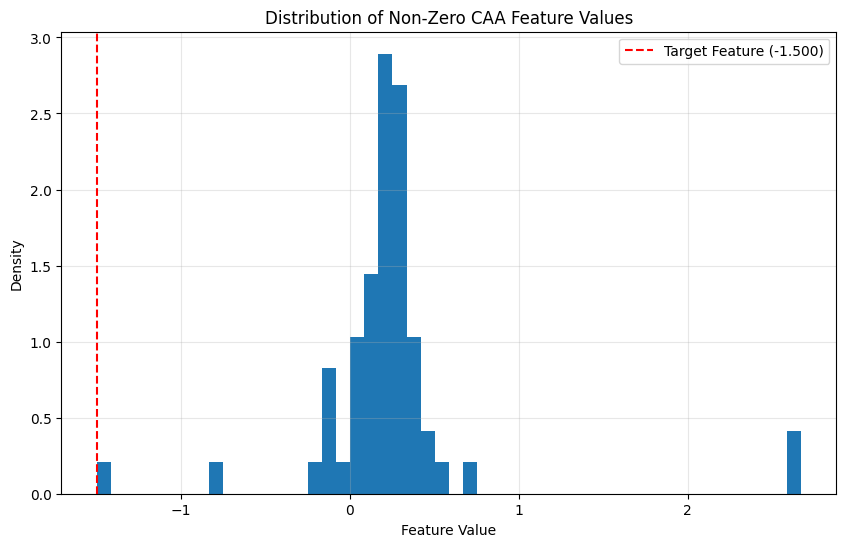

In [213]:
def normalize_relative_to_index(arr1, arr2, reference_index):
    # Get the values at the reference index
    ref_val1 = arr1[reference_index]
    ref_val2 = arr2[reference_index]
    
    # Calculate scaling factor to make them equal at reference index
    # Using the absolute max as the target value to preserve sign
    target_value = max(abs(ref_val1), abs(ref_val2))
    scale1 = target_value / ref_val1 if ref_val1 != 0 else 1
    scale2 = target_value / ref_val2 if ref_val2 != 0 else 1
    
    # Apply scaling
    normalized1 = arr1 * scale1
    normalized2 = arr2 * scale2
    
    return normalized1, normalized2

# Apply the normalization
normalized_steered, normalized_base = normalize_relative_to_index(
    top_features_steered, 
    top_features, 
    25784
)

# Calculate the difference after normalization
normalized_diff = normalized_steered - normalized_base

# Plot the normalized difference
plot_feature_distribution(normalized_diff, MODEL_NAME, client, pirate_feature_index)

/tmp/ipykernel_14870/2815162116.py:70: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = stats.pearsonr(window_orig, window_reenc)[0]


Analysis Summary:
Mean absolute change: 0.0008
Median relative change: 0.0000
Feature preservation correlation: 0.9119

Steered Feature Analysis (index 58644):
Original value: 12.0625
Re-encoded value: 11.0000
Absolute change: 1.0625
Relative change: 0.0881
Number of non-zero features: 50

Feature descriptions:

Feature 49626 (2.828): Discussions and explanations of One Piece anime/manga lore

Feature 29446 (2.664): The assistant should roleplay as a pirate

Feature 58644 (-1.062): The assistant should roleplay as a pirate
Target feature!

Feature 49225 (1.023): Technical and legal discourse about maritime vessels and shipping

Feature 27996 (-0.996): The assistant should speak in British English dialects

Feature 37219 (0.848): Maritime and naval concepts across languages

Feature 21168 (0.766): Words containing the morpheme 'pir' across different languages and contexts

Feature 53081 (0.660): Detailed descriptions of bustling indoor and outdoor gathering spaces

Feature 61928 (0.615)

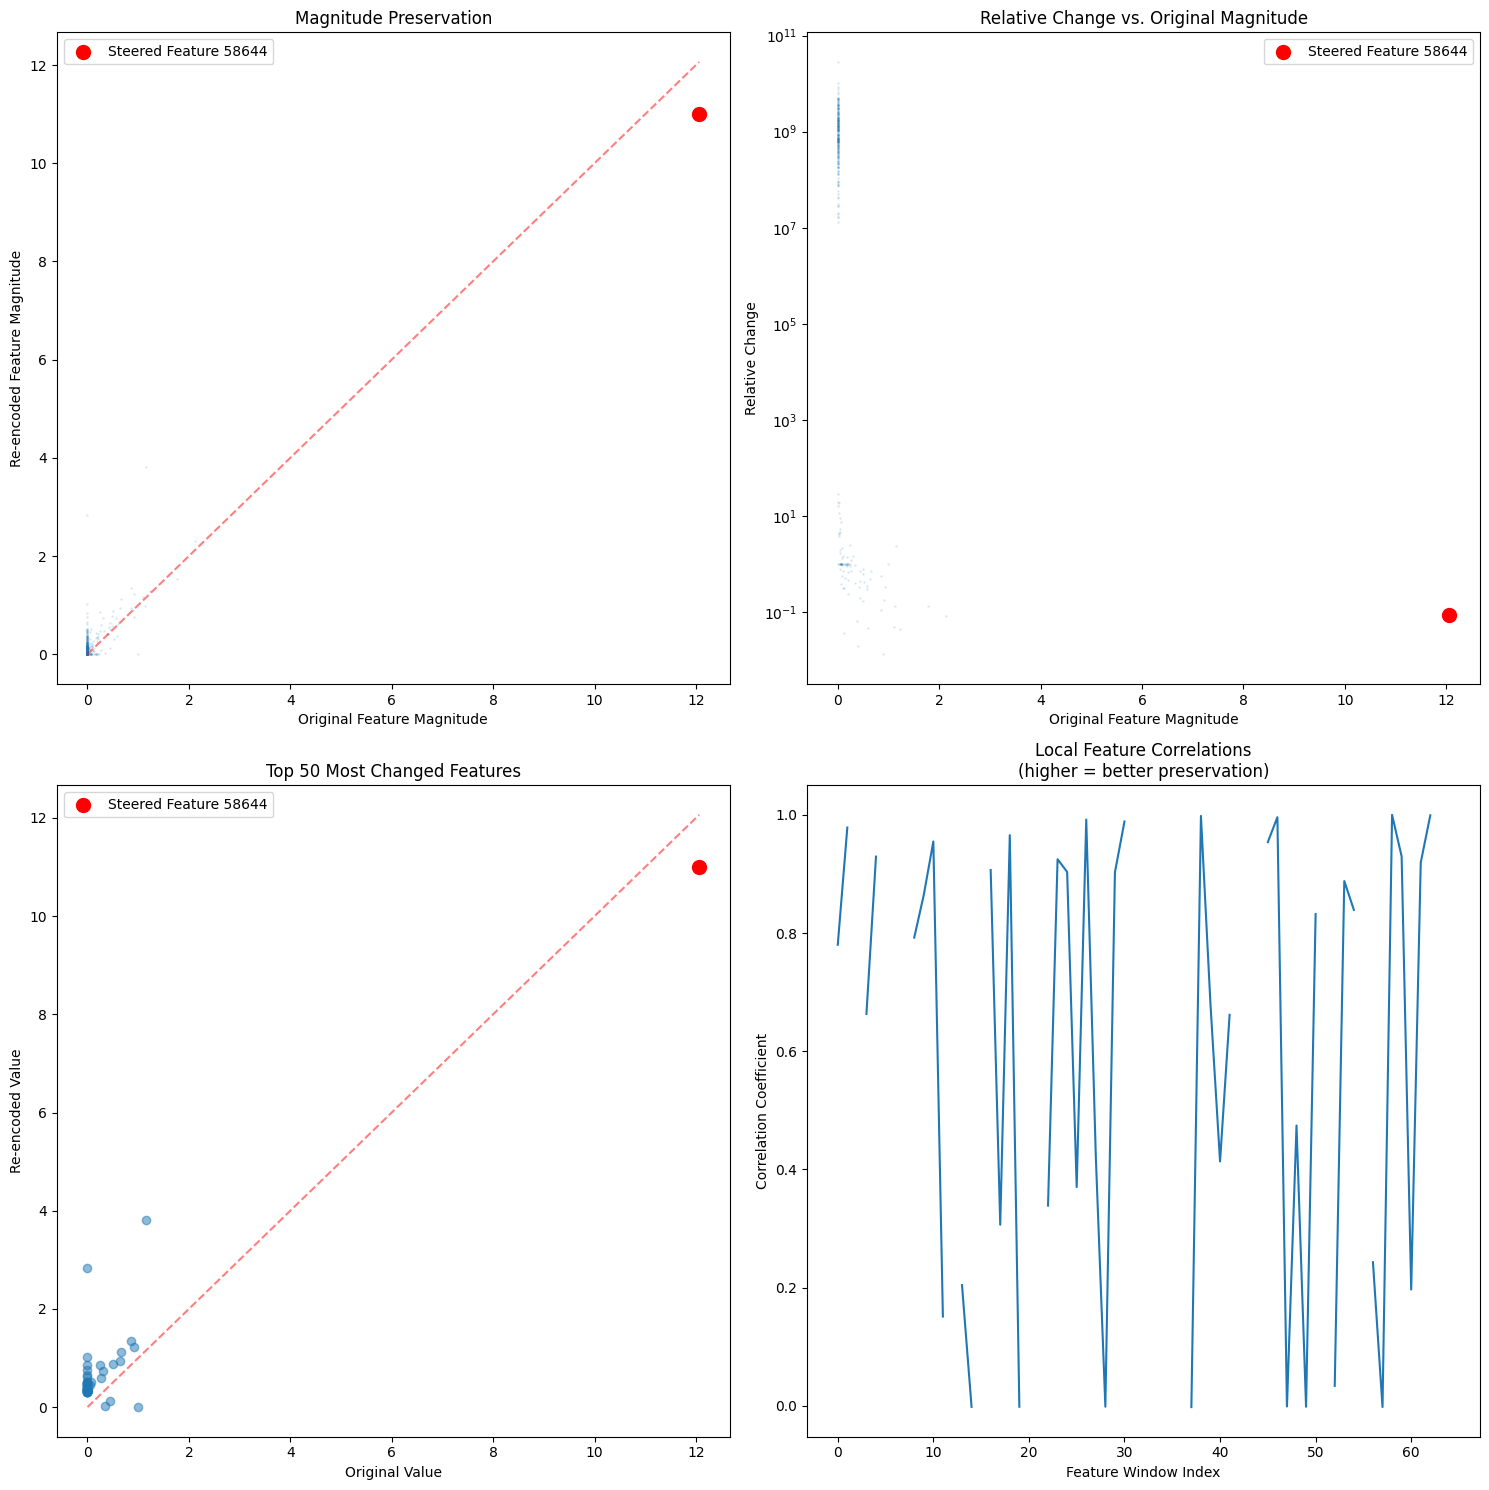

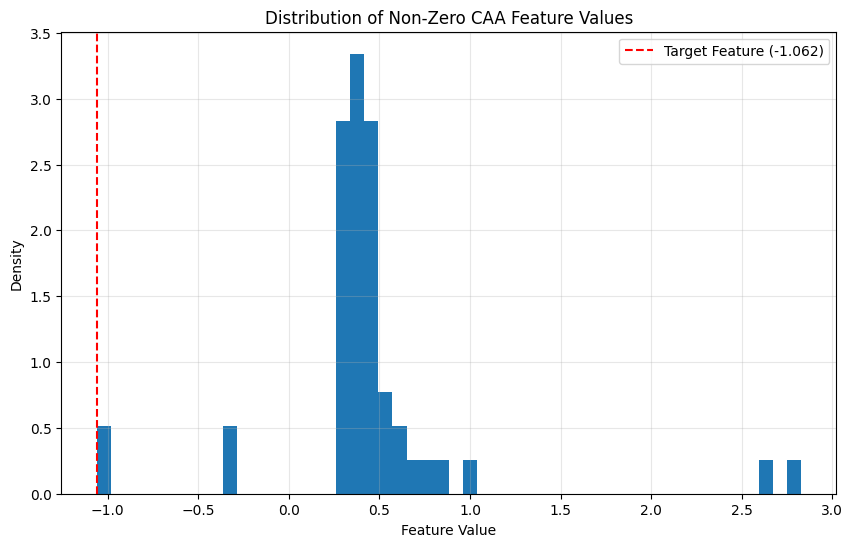

In [216]:
top_features_with_error = analyze_encoding_cycle(steered_latents, encoded_decoded_steered_acts_with_error, feature_index=pirate_feature_index)
plot_feature_distribution(top_features_with_error, MODEL_NAME, client, pirate_feature_index)

Number of non-zero features: 74

Feature descriptions:

Feature 30067 (0.955): Searching for abstract meaning or purpose

Feature 24829 (0.891): Active searching or pursuit of goals

Feature 10818 (0.773): Narrative sequences describing growing interpersonal connections through conversation

Feature 46768 (0.711): Placeholder tokens in NAME_X format

Feature 62198 (0.633): Showing genuine care or interest in someone's wellbeing

Feature 61928 (0.615): Spanish language formal response openings with proper punctuation

Feature 45630 (0.602): The root morpheme 'fer' in non-English words related to iron, railways, and farming

Feature 45862 (0.586): Syllables containing hard consonants followed by 'er', especially in words about transformation or mythological entities

Feature 23806 (0.564): The assistant is offering additional help or clarification

Feature 21168 (0.535): Words containing the morpheme 'pir' across different languages and contexts

Feature 8934 (0.525): Grammatical connect

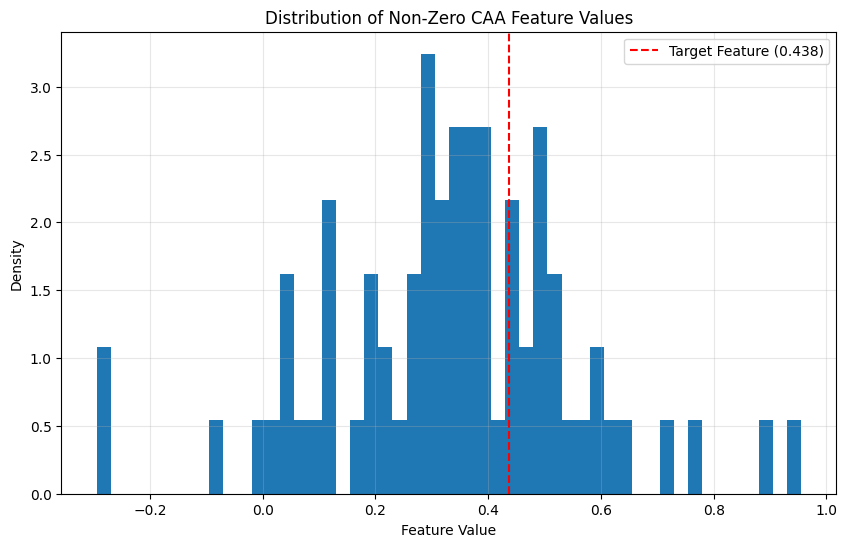

In [217]:
top_features_diff_steered_error = top_features_with_error - top_features_steered
plot_feature_distribution(top_features_diff_steered_error, MODEL_NAME, client, pirate_feature_index)


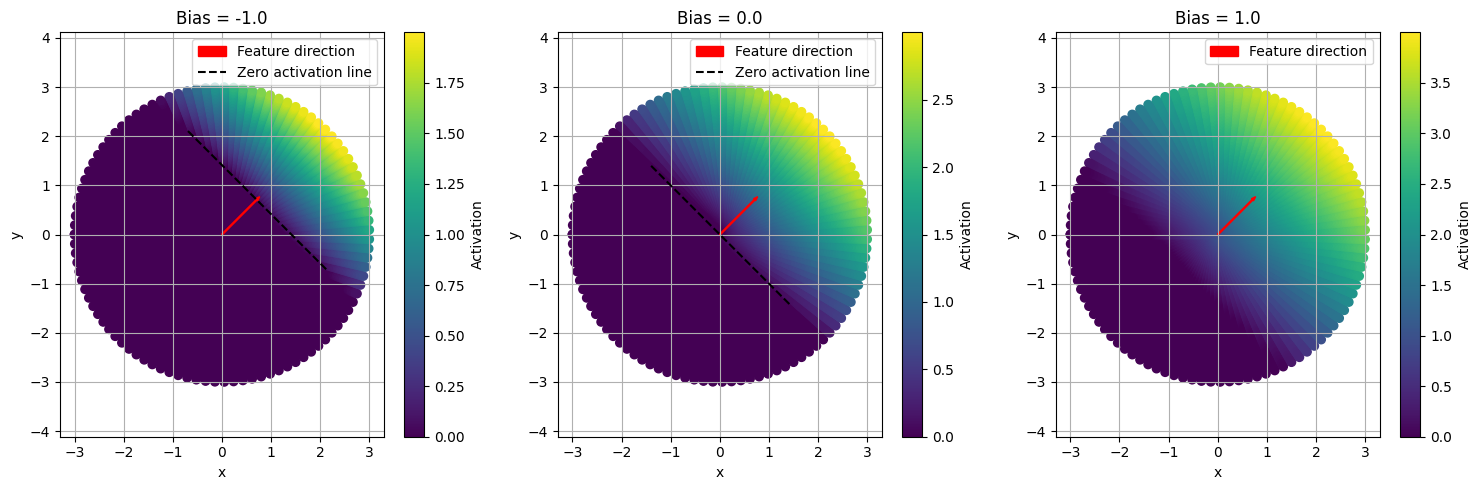

In [84]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

# Let's create a simple example with a single feature detector
# Imagine we're looking for a specific pattern in 2D space

# Create our feature detector (weight column)
feature_direction = np.array([1, 1])  # 45-degree direction
feature_direction = feature_direction / np.linalg.norm(feature_direction)  # normalize it

# Create a range of input points along and around this direction
thetas = np.linspace(-np.pi, np.pi, 100)
magnitudes = np.linspace(0, 3, 100)
X, Y = np.meshgrid(magnitudes, thetas)

# Generate input points
points = []
activations_no_bias = []
for theta in thetas:
    for magnitude in magnitudes:
        # Create point with given magnitude and angle
        point = magnitude * np.array([np.cos(theta), np.sin(theta)])
        points.append(point)
        # Calculate activation without bias
        activation = np.dot(point, feature_direction)
        activations_no_bias.append(activation)

points = np.array(points)

# Let's look at different bias values
biases = [-1.0, 0.0, 1.0]
plt.figure(figsize=(15, 5))

for idx, bias in enumerate(biases):
    # Calculate activations with ReLU and bias
    activations = np.maximum(0, np.dot(points, feature_direction) + bias)
    
    plt.subplot(1, 3, idx + 1)
    plt.scatter(points[:, 0], points[:, 1], c=activations, cmap='viridis')
    plt.colorbar(label='Activation')
    plt.title(f'Bias = {bias}')
    plt.xlabel('x')
    plt.ylabel('y')
    
    # Plot feature direction
    plt.arrow(0, 0, feature_direction[0], feature_direction[1], 
              color='red', width=0.02, label='Feature direction')
    
    # Plot decision boundary (where activation becomes non-zero)
    if bias <= 0:
        # Draw perpendicular line at distance |bias| opposite to feature direction
        perp_point = -bias * feature_direction
        perp_dir = np.array([-feature_direction[1], feature_direction[0]])
        plt.plot([perp_point[0] - 2*perp_dir[0], perp_point[0] + 2*perp_dir[0]],
                [perp_point[1] - 2*perp_dir[1], perp_point[1] + 2*perp_dir[1]],
                'k--', label='Zero activation line')
    
    plt.axis('equal')
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

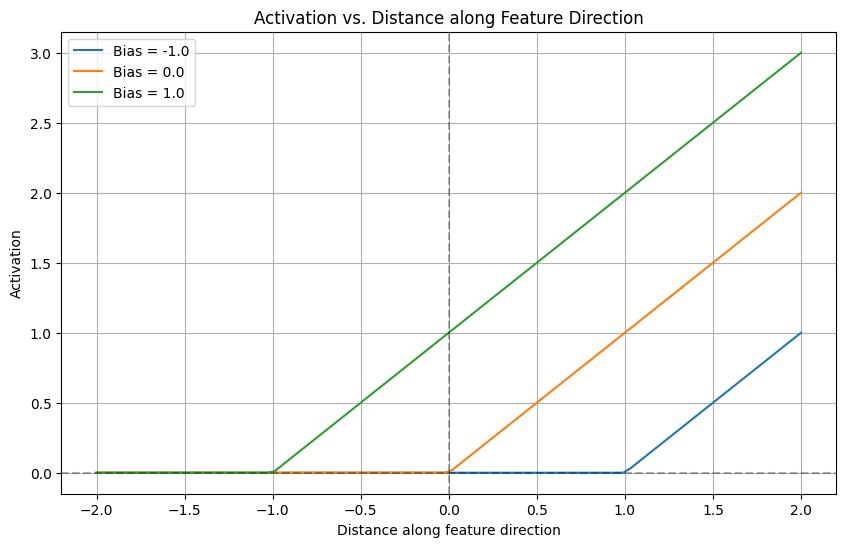

In [85]:
# Look at activations along feature direction
magnitudes = np.linspace(-2, 2, 100)
points = np.outer(magnitudes, feature_direction)

plt.figure(figsize=(10, 6))
for bias in [-1.0, 0.0, 1.0]:
    activations = np.maximum(0, np.dot(points, feature_direction) + bias)
    plt.plot(magnitudes, activations, label=f'Bias = {bias}')

plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.grid(True)
plt.xlabel('Distance along feature direction')
plt.ylabel('Activation')
plt.title('Activation vs. Distance along Feature Direction')
plt.legend()
plt.show()

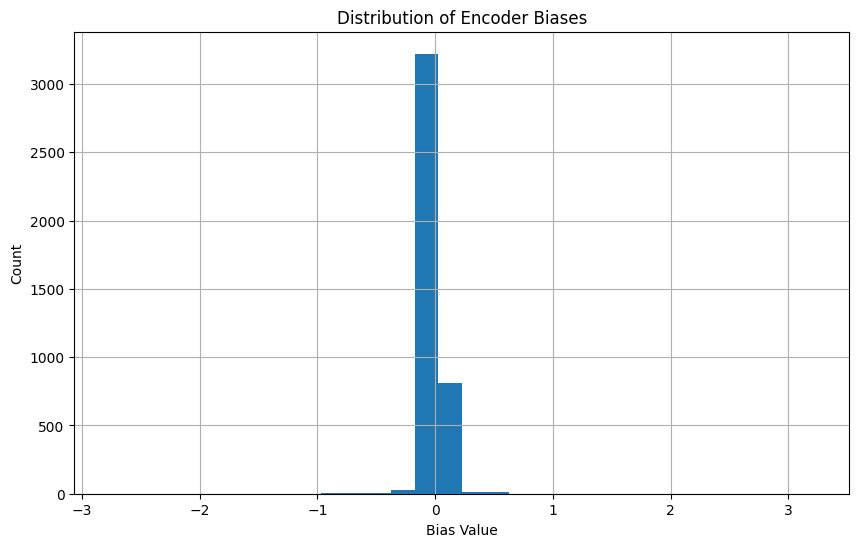

In [99]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Let's create a simplified example first to build intuition
np.random.seed(42)

# Now let's look at your actual SAE encoder bias
# Assuming 'sae' is your model
bias = sae.decoder_linear.bias.detach().cpu().float().numpy()

# Plot histogram of bias values
plt.figure(figsize=(10, 6))
nonzero_bias = bias[bias != 0]
plt.hist(nonzero_bias, bins=30)
plt.title("Distribution of Encoder Biases")
plt.xlabel("Bias Value")
plt.ylabel("Count")
plt.grid(True)
plt.show()

In [100]:
nonzero_bias.shape

(4096,)

In [96]:
sae.decoder_linear.bias.shape

torch.Size([4096])

In [97]:
import numpy as np
np.random.seed(42)

# Let's say:
residual_dim = 4
latent_dim = 3

# Create example decoder weights
# Each column represents how one latent feature affects the residual stream
decoder_weights = np.array([
    [2.0, 0.1, -0.5],    # How each feature affects position 1
    [-0.5, 1.8, 0.2],    # How each feature affects position 2
    [0.3, -0.4, 1.5],    # How each feature affects position 3
    [0.1, 0.2, -0.3]     # How each feature affects position 4
])

# Let's say feature 1 is strongly active in our latent space
latent = np.array([1.0, 0.0, 0.0])  # Only first feature is "on"

# See how this affects the residual stream
reconstruction = np.matmul(decoder_weights, latent)
print("Reconstruction when feature 1 is active:", reconstruction)

# Now let's see what each feature does independently
print("\nEffect of each feature when activated:")
for i in range(latent_dim):
    feature_vector = np.zeros(latent_dim)
    feature_vector[i] = 1.0
    effect = np.matmul(decoder_weights, feature_vector)
    print(f"\nFeature {i+1} contribution:", effect)

Reconstruction when feature 1 is active: [ 2.  -0.5  0.3  0.1]

Effect of each feature when activated:

Feature 1 contribution: [ 2.  -0.5  0.3  0.1]

Feature 2 contribution: [ 0.1  1.8 -0.4  0.2]

Feature 3 contribution: [-0.5  0.2  1.5 -0.3]


In [98]:
import numpy as np
np.random.seed(42)

# Simple example
residual_dim = 4
latent_dim = 2

# Create encoder
encoder_weights = np.array([
    [1.0, -0.5, 0.3, 0.2],
    [-0.5, 1.0, 0.7, 0.4]
]).T
encoder_bias = np.array([-0.5, -0.5])

# Create decoder
decoder_weights = encoder_weights  # simplified case
decoder_bias = np.array([0.3, 0.3, 0.3, 0.3])  # positive bias

# Let's see what happens with some inputs
inputs = [
    np.array([1.0, -1.0, 0.5, 0.0]),  # input 1
    np.array([-1.0, 1.0, -0.5, 0.0]),  # opposite of input 1
]

for i, x in enumerate(inputs):
    print(f"\nInput {i+1}:", x)
    
    # Encode
    latent_pre_relu = np.dot(x, encoder_weights) + encoder_bias
    print("Pre-ReLU:", latent_pre_relu)
    latent = np.maximum(0, latent_pre_relu)
    print("Post-ReLU:", latent)
    
    # Decode without bias
    reconstruction_no_bias = np.dot(decoder_weights, latent)
    print("Reconstruction (no bias):", reconstruction_no_bias)
    
    # Decode with bias
    reconstruction_with_bias = reconstruction_no_bias + decoder_bias
    print("Reconstruction (with bias):", reconstruction_with_bias)


Input 1: [ 1.  -1.   0.5  0. ]
Pre-ReLU: [ 1.15 -1.65]
Post-ReLU: [1.15 0.  ]
Reconstruction (no bias): [ 1.15  -0.575  0.345  0.23 ]
Reconstruction (with bias): [ 1.45  -0.275  0.645  0.53 ]

Input 2: [-1.   1.  -0.5  0. ]
Pre-ReLU: [-2.15  0.65]
Post-ReLU: [0.   0.65]
Reconstruction (no bias): [-0.325  0.65   0.455  0.26 ]
Reconstruction (with bias): [-0.025  0.95   0.755  0.56 ]


In [83]:
import torch

def check_row_norms(weight_matrix, name="matrix"):
    # Compute row norms (l2 norm along dim 1)
    norms = torch.norm(weight_matrix, p=2, dim=1)
    
    # Check how close norms are to 1
    is_unit = torch.isclose(norms, torch.ones_like(norms), atol=1e-5)
    all_unit = is_unit.all().item()
    
    print(f"\n{name} row norms:")
    print(f"Shape: {weight_matrix.shape}")
    print(f"Mean norm: {norms.mean().item():.6f}")
    print(f"Min norm: {norms.min().item():.6f}")
    print(f"Max norm: {norms.max().item():.6f}")
    print(f"Std of norms: {norms.std().item():.6f}")
    print(f"All rows unit norm? {all_unit}")
    
    if not all_unit:
        print(f"Number of non-unit rows: {(~is_unit).sum().item()}")

def check_column_norms(weight_matrix, name="matrix"):
    # Compute column norms (l2 norm along dim 0)
    norms = torch.norm(weight_matrix, p=2, dim=0)
    
    # Check how close norms are to 1
    is_unit = torch.isclose(norms, torch.ones_like(norms), atol=1e-5)
    all_unit = is_unit.all().item()
    
    print(f"\n{name} column norms:")
    print(f"Shape: {weight_matrix.shape}")
    print(f"Mean norm: {norms.mean().item():.6f}")
    print(f"Min norm: {norms.min().item():.6f}")
    print(f"Max norm: {norms.max().item():.6f}")
    print(f"Std of norms: {norms.std().item():.6f}")
    print(f"All columns unit norm? {all_unit}")
    
    if not all_unit:
        print(f"Number of non-unit columns: {(~is_unit).sum().item()}")

# Check decoder (4096 x 65536)
check_column_norms(sae.decoder_linear.weight, "Decoder")

# Check encoder (65536 x 4096)
check_row_norms(sae.encoder_linear.weight, "Encoder")


Decoder column norms:
Shape: torch.Size([4096, 65536])
Mean norm: 0.750000
Min norm: 0.000000
Max norm: 1.664062
Std of norms: 0.511719
All columns unit norm? False
Number of non-unit columns: 64970

Encoder row norms:
Shape: torch.Size([65536, 4096])
Mean norm: 0.906250
Min norm: 0.000000
Max norm: 3.328125
Std of norms: 0.640625
All rows unit norm? False
Number of non-unit rows: 65384


In [72]:
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Let's use a tiny example:
# Input vector (1 x 2)
x = np.array([[1, 2]])
print("Input x:", x)

# Weight matrix (2 x 3)
W = np.array([
    [0.1, 0.2, 0.3],
    [0.4, 0.5, 0.6]
])
print("\nWeight matrix W:\n", W)

# Let's compute output manually
output = np.matmul(x, W)
print("\nOutput:", output)

Input x: [[1 2]]

Weight matrix W:
 [[0.1 0.2 0.3]
 [0.4 0.5 0.6]]

Output: [[0.9 1.2 1.5]]
